# 🛰️ AFETSONAR — Notebook 2_v3 Phase 2: Damage Classification

**Calamitas AI · Teknofest 2025 · İki Aşamalı Eğitim · Aşama 2/2**

---

## 📌 Bu Notebook Ne Yapıyor?

Phase 1'in encoder weights'ini alıp, üzerine **damage classification** eğitiyor. Bu bizim **ana** öğretmen modelimiz olacak.

### Phase 2'nin Tüm İyileştirmeleri

| # | Özellik | Açıklama |
|---|---|---|
| 1 | **Encoder transfer** | Phase 1'den weights yüklüyoruz → bina sınırlarını zaten biliyor |
| 2 | **Lovász-Softmax loss** | mIoU'yu doğrudan optimize eder (xView2 winners kullanıyor) |
| 3 | **Deep supervision** | 3 auxiliary head encoder'ın ara katmanlarından, model her seviyede tahmin yapmayı öğrenir |
| 4 | **Lovász + Dice + Focal combo** | Loss bileşenleri dengeli (eski Boundary loss kaldırıldı, çok dominant olduğu için) |
| 5 | **EMA (Exponential Moving Average)** | Eğitim sırasında shadow weights, validation'da daha smooth tahminler (+1-2% mIoU) |
| 6 | **LR schedule fix** | Gradient accumulation ile uyumlu, son epoch'larda LR sıfıra düşmesin |
| 7 | **Resolution 768** | 512'den artırıldı, daha çok detay |
| 8 | **Multi-scale validation** | TTA hint: val'de full resolution, train'de crop |

### Süre

H100'de ~3-4 saat. Daha önceki başarısız 2 saatten biraz uzun ama daha sağlam.

### Hedef

mIoU_no_bg ≥ 0.55 (gerçekçi), 0.65+ ideal

---

## 1️⃣ Drive + GPU + Phase 1 Kontrolü

In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import os

PROJECT_ROOT = "/content/drive/MyDrive/AFETSONAR"
DATA_RAW     = os.path.join(PROJECT_ROOT, "data/raw/xview2")
DATA_MASKS   = os.path.join(PROJECT_ROOT, "data/processed/masks")
DATA_SPLITS  = os.path.join(PROJECT_ROOT, "data/splits")
SRC_DIR      = os.path.join(PROJECT_ROOT, "src")
CKPT_TEACHER = os.path.join(PROJECT_ROOT, "checkpoints/teacher")
OUTPUTS_VIZ  = os.path.join(PROJECT_ROOT, "outputs/visualizations")

# CRITICAL: Phase 1 var mı?
# Önce v2'yi ara (yeniden eğitilen), yoksa v1'e fall back
localizer_v2 = os.path.join(CKPT_TEACHER, "localizer_v2_best.pth")
localizer_v1 = os.path.join(CKPT_TEACHER, "localizer_best.pth")

if os.path.exists(localizer_v2):
    localizer_path = localizer_v2
    print(f"✅ Phase 1 v2 model bulundu: localizer_v2_best.pth")
elif os.path.exists(localizer_v1):
    localizer_path = localizer_v1
    print(f"⚠️  Phase 1 v2 yok, v1 kullanılıyor: localizer_best.pth")
else:
    raise FileNotFoundError(
        "❌ Phase 1 model bulunamadı!\n"
        "Önce 02_v3_phase1_v2_localization.ipynb (veya 02_v3_phase1_localization.ipynb) çalıştırılmalı."
    )

print(f"✅ Drive bağlandı")
print(f"📂 Localizer path: {localizer_path}")

# === GPU ===
import torch
gpu_name = torch.cuda.get_device_name(0)
vram_gb = round(torch.cuda.get_device_properties(0).total_memory / 1024**3, 1)
bf16_supported = torch.cuda.is_bf16_supported()
print(f"\n⚙️  {gpu_name}, VRAM: {vram_gb} GB")

# Phase 2 Siamese (2x bellek), 768 res
if "H100" in gpu_name:
    BATCH_SIZE = 8
    GRAD_ACCUM_STEPS = 4   # efektif 32
    NUM_WORKERS = 8
elif "A100" in gpu_name:
    BATCH_SIZE = 4
    GRAD_ACCUM_STEPS = 8
    NUM_WORKERS = 6
elif "L4" in gpu_name or "V100" in gpu_name:
    BATCH_SIZE = 2
    GRAD_ACCUM_STEPS = 8
    NUM_WORKERS = 4
elif "T4" in gpu_name:
    BATCH_SIZE = 1
    GRAD_ACCUM_STEPS = 16
    NUM_WORKERS = 2
else:
    BATCH_SIZE = 4
    GRAD_ACCUM_STEPS = 8
    NUM_WORKERS = 4

EFFECTIVE_BATCH = BATCH_SIZE * GRAD_ACCUM_STEPS
PRECISION = "bf16" if bf16_supported else "fp16"
device = torch.device("cuda")
IMAGE_SIZE = 768

print(f"\n📊 Phase 2 Ayarlar:")
print(f"  micro batch     = {BATCH_SIZE}")
print(f"  grad accum      = {GRAD_ACCUM_STEPS}")
print(f"  effective batch = {EFFECTIVE_BATCH}")
print(f"  image size      = {IMAGE_SIZE}")
print(f"  precision       = {PRECISION}")

Mounted at /content/drive
✅ Phase 1 v2 model bulundu: localizer_v2_best.pth
✅ Drive bağlandı
📂 Localizer path: /content/drive/MyDrive/AFETSONAR/checkpoints/teacher/localizer_v2_best.pth

⚙️  NVIDIA A100-SXM4-80GB, VRAM: 79.3 GB

📊 Phase 2 Ayarlar:
  micro batch     = 4
  grad accum      = 8
  effective batch = 32
  image size      = 768
  precision       = bf16


## 2️⃣ Modülleri Yaz (idempotent)

In [ ]:
import os
import base64

MODELS_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBNb2RlbHMgdjMuCgpUd28gbW9kZWwgY2xhc3NlczoKLSBMb2NhbGl6ZXJTZWdmb3JtZXI6IFBoYXNlIDEsIGJpbmFyeSBidWlsZGluZyBsb2NhbGl6YXRpb24KLSBTaWFtZXNlVGVhY2hlclNlZ2Zvcm1lclYzOiBQaGFzZSAyLCBkYW1hZ2UgY2xhc3NpZmljYXRpb24gd2l0aCBkZWVwIHN1cGVydmlzaW9uCiIiIgoKaW1wb3J0IHRvcmNoCmltcG9ydCB0b3JjaC5ubiBhcyBubgppbXBvcnQgdG9yY2gubm4uZnVuY3Rpb25hbCBhcyBGCmZyb20gdHJhbnNmb3JtZXJzIGltcG9ydCBTZWdmb3JtZXJGb3JTZW1hbnRpY1NlZ21lbnRhdGlvbiwgU2VnZm9ybWVyQ29uZmlnCgoKY2xhc3MgTG9jYWxpemVyU2VnZm9ybWVyKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBiYWNrYm9uZV9uYW1lPSJudmlkaWEvc2VnZm9ybWVyLWIzLWZpbmV0dW5lZC1hZGUtNTEyLTUxMiIsCiAgICAgICAgcHJldHJhaW5lZD1UcnVlLAogICAgKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBpZiBwcmV0cmFpbmVkOgogICAgICAgICAgICBzZWxmLnNlZ2Zvcm1lciA9IFNlZ2Zvcm1lckZvclNlbWFudGljU2VnbWVudGF0aW9uLmZyb21fcHJldHJhaW5lZCgKICAgICAgICAgICAgICAgIGJhY2tib25lX25hbWUsCiAgICAgICAgICAgICAgICBudW1fbGFiZWxzPTIsCiAgICAgICAgICAgICAgICBpZ25vcmVfbWlzbWF0Y2hlZF9zaXplcz1UcnVlLAogICAgICAgICAgICApCiAgICAgICAgZWxzZToKICAgICAgICAgICAgY29uZmlnID0gU2VnZm9ybWVyQ29uZmlnLmZyb21fcHJldHJhaW5lZChiYWNrYm9uZV9uYW1lKQogICAgICAgICAgICBjb25maWcubnVtX2xhYmVscyA9IDIKICAgICAgICAgICAgc2VsZi5zZWdmb3JtZXIgPSBTZWdmb3JtZXJGb3JTZW1hbnRpY1NlZ21lbnRhdGlvbihjb25maWcpCgogICAgZGVmIGZvcndhcmQoc2VsZiwgeCk6CiAgICAgICAgQiwgQywgSCwgVyA9IHguc2hhcGUKICAgICAgICBvdXRwdXRzID0gc2VsZi5zZWdmb3JtZXIoeCkKICAgICAgICBsb2dpdHMgPSBvdXRwdXRzLmxvZ2l0cwogICAgICAgIGxvZ2l0cyA9IEYuaW50ZXJwb2xhdGUobG9naXRzLCBzaXplPShILCBXKSwgbW9kZT0iYmlsaW5lYXIiLCBhbGlnbl9jb3JuZXJzPUZhbHNlKQogICAgICAgIHJldHVybiBsb2dpdHMKCiAgICBkZWYgZ2V0X2VuY29kZXJfc3RhdGVfZGljdChzZWxmKToKICAgICAgICBlbmNvZGVyX3N0YXRlID0ge30KICAgICAgICBmb3IgbmFtZSwgcGFyYW0gaW4gc2VsZi5zZWdmb3JtZXIuc2VnZm9ybWVyLmVuY29kZXIuc3RhdGVfZGljdCgpLml0ZW1zKCk6CiAgICAgICAgICAgIGVuY29kZXJfc3RhdGVbbmFtZV0gPSBwYXJhbQogICAgICAgIHJldHVybiBlbmNvZGVyX3N0YXRlCgogICAgZGVmIGVuYWJsZV9ncmFkaWVudF9jaGVja3BvaW50aW5nKHNlbGYpOgogICAgICAgIGlmIGhhc2F0dHIoc2VsZi5zZWdmb3JtZXIuc2VnZm9ybWVyLmVuY29kZXIsICJncmFkaWVudF9jaGVja3BvaW50aW5nX2VuYWJsZSIpOgogICAgICAgICAgICBzZWxmLnNlZ2Zvcm1lci5zZWdmb3JtZXIuZW5jb2Rlci5ncmFkaWVudF9jaGVja3BvaW50aW5nX2VuYWJsZSgpCiAgICAgICAgICAgIHJldHVybiBUcnVlCiAgICAgICAgcmV0dXJuIEZhbHNlCgogICAgZGVmIG51bV9wYXJhbWV0ZXJzKHNlbGYpOgogICAgICAgIHJldHVybiBzdW0ocC5udW1lbCgpIGZvciBwIGluIHNlbGYucGFyYW1ldGVycygpIGlmIHAucmVxdWlyZXNfZ3JhZCkKCgpjbGFzcyBTaWFtZXNlVGVhY2hlclNlZ2Zvcm1lclYzKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oCiAgICAgICAgc2VsZiwKICAgICAgICBiYWNrYm9uZV9uYW1lPSJudmlkaWEvc2VnZm9ybWVyLWIzLWZpbmV0dW5lZC1hZGUtNTEyLTUxMiIsCiAgICAgICAgbnVtX2RhbWFnZV9jbGFzc2VzPTYsCiAgICAgICAgbnVtX2Rpc2FzdGVyX2NsYXNzZXM9NSwKICAgICAgICBwcmV0cmFpbmVkPVRydWUsCiAgICAgICAgdXNlX2RlZXBfc3VwZXJ2aXNpb249VHJ1ZSwKICAgICk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5udW1fZGFtYWdlX2NsYXNzZXMgPSBudW1fZGFtYWdlX2NsYXNzZXMKICAgICAgICBzZWxmLm51bV9kaXNhc3Rlcl9jbGFzc2VzID0gbnVtX2Rpc2FzdGVyX2NsYXNzZXMKICAgICAgICBzZWxmLnVzZV9kZWVwX3N1cGVydmlzaW9uID0gdXNlX2RlZXBfc3VwZXJ2aXNpb24KCiAgICAgICAgaWYgcHJldHJhaW5lZDoKICAgICAgICAgICAgYmFzZV9tb2RlbCA9IFNlZ2Zvcm1lckZvclNlbWFudGljU2VnbWVudGF0aW9uLmZyb21fcHJldHJhaW5lZCgKICAgICAgICAgICAgICAgIGJhY2tib25lX25hbWUsCiAgICAgICAgICAgICAgICBudW1fbGFiZWxzPW51bV9kYW1hZ2VfY2xhc3NlcywKICAgICAgICAgICAgICAgIGlnbm9yZV9taXNtYXRjaGVkX3NpemVzPVRydWUsCiAgICAgICAgICAgICkKICAgICAgICBlbHNlOgogICAgICAgICAgICBjb25maWcgPSBTZWdmb3JtZXJDb25maWcuZnJvbV9wcmV0cmFpbmVkKGJhY2tib25lX25hbWUpCiAgICAgICAgICAgIGNvbmZpZy5udW1fbGFiZWxzID0gbnVtX2RhbWFnZV9jbGFzc2VzCiAgICAgICAgICAgIGJhc2VfbW9kZWwgPSBTZWdmb3JtZXJGb3JTZW1hbnRpY1NlZ21lbnRhdGlvbihjb25maWcpCgogICAgICAgIHNlbGYuZW5jb2RlciA9IGJhc2VfbW9kZWwuc2VnZm9ybWVyLmVuY29kZXIKICAgICAgICBzZWxmLmRlY29kZV9oZWFkID0gYmFzZV9tb2RlbC5kZWNvZGVfaGVhZAoKICAgICAgICBlbmNvZGVyX2NoYW5uZWxzID0gYmFzZV9tb2RlbC5jb25maWcuaGlkZGVuX3NpemVzICAjIFs2NCwgMTI4LCAzMjAsIDUxMl0KICAgICAgICBzZWxmLmVuY29kZXJfY2hhbm5lbHMgPSBlbmNvZGVyX2NoYW5uZWxzCgogICAgICAgIHNlbGYuZnVzaW9uX2NvbnZzID0gbm4uTW9kdWxlTGlzdChbCiAgICAgICAgICAgIG5uLlNlcXVlbnRpYWwoCiAgICAgICAgICAgICAgICBubi5Db252MmQoY2ggKiAzLCBjaCwga2VybmVsX3NpemU9MSwgYmlhcz1GYWxzZSksCiAgICAgICAgICAgICAgICBubi5CYXRjaE5vcm0yZChjaCksCiAgICAgICAgICAgICAgICBubi5SZUxVKGlucGxhY2U9VHJ1ZSksCiAgICAgICAgICAgICkKICAgICAgICAgICAgZm9yIGNoIGluIGVuY29kZXJfY2hhbm5lbHMKICAgICAgICBdKQoKICAgICAgICBpZiB1c2VfZGVlcF9zdXBlcnZpc2lvbjoKICAgICAgICAgICAgc2VsZi5hdXhfaGVhZHMgPSBubi5Nb2R1bGVMaXN0KFsKICAgICAgICAgICAgICAgIG5uLlNlcXVlbnRpYWwoCiAgICAgICAgICAgICAgICAgICAgbm4uQ29udjJkKGNoLCBjaCAvLyAyLCBrZXJuZWxfc2l6ZT0zLCBwYWRkaW5nPTEpLAogICAgICAgICAgICAgICAgICAgIG5uLkJhdGNoTm9ybTJkKGNoIC8vIDIpLAogICAgICAgICAgICAgICAgICAgIG5uLlJlTFUoaW5wbGFjZT1UcnVlKSwKICAgICAgICAgICAgICAgICAgICBubi5Ecm9wb3V0MmQoMC4xKSwKICAgICAgICAgICAgICAgICAgICBubi5Db252MmQoY2ggLy8gMiwgbnVtX2RhbWFnZV9jbGFzc2VzLCBrZXJuZWxfc2l6ZT0xKSwKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgICAgIGZvciBjaCBpbiBlbmNvZGVyX2NoYW5uZWxzWzotMV0KICAgICAgICAgICAgXSkKICAgICAgICBlbHNlOgogICAgICAgICAgICBzZWxmLmF1eF9oZWFkcyA9IE5vbmUKCiAgICAgICAgbGFzdF9kaW0gPSBlbmNvZGVyX2NoYW5uZWxzWy0xXQogICAgICAgIHNlbGYuY2hhbmdlX2hlYWQgPSBubi5TZXF1ZW50aWFsKAogICAgICAgICAgICBubi5Db252MmQobGFzdF9kaW0sIDI1Niwga2VybmVsX3NpemU9MywgcGFkZGluZz0xKSwKICAgICAgICAgICAgbm4uQmF0Y2hOb3JtMmQoMjU2KSwKICAgICAgICAgICAgbm4uUmVMVShpbnBsYWNlPVRydWUpLAogICAgICAgICAgICBubi5Ecm9wb3V0MmQoMC4xKSwKICAgICAgICAgICAgbm4uQ29udjJkKDI1NiwgMiwga2VybmVsX3NpemU9MSksCiAgICAgICAgKQoKICAgICAgICBzZWxmLmRpc2FzdGVyX2hlYWQgPSBubi5TZXF1ZW50aWFsKAogICAgICAgICAgICBubi5BZGFwdGl2ZUF2Z1Bvb2wyZCgxKSwKICAgICAgICAgICAgbm4uRmxhdHRlbigpLAogICAgICAgICAgICBubi5MaW5lYXIobGFzdF9kaW0sIDI1NiksCiAgICAgICAgICAgIG5uLlJlTFUoaW5wbGFjZT1UcnVlKSwKICAgICAgICAgICAgbm4uRHJvcG91dCgwLjMpLAogICAgICAgICAgICBubi5MaW5lYXIoMjU2LCBudW1fZGlzYXN0ZXJfY2xhc3NlcyksCiAgICAgICAgKQoKICAgIGRlZiBfZW5jb2RlKHNlbGYsIHgpOgogICAgICAgIG91dHB1dHMgPSBzZWxmLmVuY29kZXIoeCwgb3V0cHV0X2hpZGRlbl9zdGF0ZXM9VHJ1ZSwgcmV0dXJuX2RpY3Q9VHJ1ZSkKICAgICAgICByZXR1cm4gbGlzdChvdXRwdXRzLmhpZGRlbl9zdGF0ZXMpCgogICAgZGVmIF9mdXNlX2ZlYXR1cmVzKHNlbGYsIGZlYXR1cmVzX3ByZSwgZmVhdHVyZXNfcG9zdCk6CiAgICAgICAgZnVzZWQgPSBbXQogICAgICAgIGZvciBpLCAocHJlLCBwb3N0KSBpbiBlbnVtZXJhdGUoemlwKGZlYXR1cmVzX3ByZSwgZmVhdHVyZXNfcG9zdCkpOgogICAgICAgICAgICBkaWZmID0gdG9yY2guYWJzKHBvc3QgLSBwcmUpCiAgICAgICAgICAgIGNvbWJpbmVkID0gdG9yY2guY2F0KFtwcmUsIHBvc3QsIGRpZmZdLCBkaW09MSkKICAgICAgICAgICAgZnVzZWRfZmVhdCA9IHNlbGYuZnVzaW9uX2NvbnZzW2ldKGNvbWJpbmVkKQogICAgICAgICAgICBmdXNlZC5hcHBlbmQoZnVzZWRfZmVhdCkKICAgICAgICByZXR1cm4gZnVzZWQKCiAgICBkZWYgZm9yd2FyZChzZWxmLCB4KToKICAgICAgICBCLCBDLCBILCBXID0geC5zaGFwZQogICAgICAgIGFzc2VydCBDID09IDYsIGYiRXhwZWN0ZWQgNiBjaGFubmVscywgZ290IHtDfSIKCiAgICAgICAgcHJlID0geFs6LCA6M10KICAgICAgICBwb3N0ID0geFs6LCAzOl0KCiAgICAgICAgZmVhdHVyZXNfcHJlID0gc2VsZi5fZW5jb2RlKHByZSkKICAgICAgICBmZWF0dXJlc19wb3N0ID0gc2VsZi5fZW5jb2RlKHBvc3QpCiAgICAgICAgZnVzZWRfZmVhdHVyZXMgPSBzZWxmLl9mdXNlX2ZlYXR1cmVzKGZlYXR1cmVzX3ByZSwgZmVhdHVyZXNfcG9zdCkKCiAgICAgICAgZGVjb2Rlcl9vdXRwdXQgPSBzZWxmLmRlY29kZV9oZWFkKGZ1c2VkX2ZlYXR1cmVzKQogICAgICAgIGRhbWFnZV9tYWluID0gRi5pbnRlcnBvbGF0ZSgKICAgICAgICAgICAgZGVjb2Rlcl9vdXRwdXQsCiAgICAgICAgICAgIHNpemU9KEgsIFcpLAogICAgICAgICAgICBtb2RlPSJiaWxpbmVhciIsCiAgICAgICAgICAgIGFsaWduX2Nvcm5lcnM9RmFsc2UsCiAgICAgICAgKQoKICAgICAgICBpZiBzZWxmLnVzZV9kZWVwX3N1cGVydmlzaW9uIGFuZCBzZWxmLmF1eF9oZWFkcyBpcyBub3QgTm9uZToKICAgICAgICAgICAgZGFtYWdlX2xvZ2l0c19saXN0ID0gW2RhbWFnZV9tYWluXQogICAgICAgICAgICBmb3IgaSwgYXV4X2hlYWQgaW4gZW51bWVyYXRlKHNlbGYuYXV4X2hlYWRzKToKICAgICAgICAgICAgICAgIGF1eF9sb2dpdHMgPSBhdXhfaGVhZChmdXNlZF9mZWF0dXJlc1tpXSkKICAgICAgICAgICAgICAgIGF1eF9sb2dpdHMgPSBGLmludGVycG9sYXRlKAogICAgICAgICAgICAgICAgICAgIGF1eF9sb2dpdHMsCiAgICAgICAgICAgICAgICAgICAgc2l6ZT0oSCwgVyksCiAgICAgICAgICAgICAgICAgICAgbW9kZT0iYmlsaW5lYXIiLAogICAgICAgICAgICAgICAgICAgIGFsaWduX2Nvcm5lcnM9RmFsc2UsCiAgICAgICAgICAgICAgICApCiAgICAgICAgICAgICAgICBkYW1hZ2VfbG9naXRzX2xpc3QuYXBwZW5kKGF1eF9sb2dpdHMpCiAgICAgICAgICAgIGRhbWFnZV9vdXRwdXQgPSBkYW1hZ2VfbG9naXRzX2xpc3QKICAgICAgICBlbHNlOgogICAgICAgICAgICBkYW1hZ2Vfb3V0cHV0ID0gZGFtYWdlX21haW4KCiAgICAgICAgbGFzdF9mdXNlZCA9IGZ1c2VkX2ZlYXR1cmVzWy0xXQogICAgICAgIGNoYW5nZV9sb3cgPSBzZWxmLmNoYW5nZV9oZWFkKGxhc3RfZnVzZWQpCiAgICAgICAgY2hhbmdlX2xvZ2l0cyA9IEYuaW50ZXJwb2xhdGUoCiAgICAgICAgICAgIGNoYW5nZV9sb3csCiAgICAgICAgICAgIHNpemU9KEgsIFcpLAogICAgICAgICAgICBtb2RlPSJiaWxpbmVhciIsCiAgICAgICAgICAgIGFsaWduX2Nvcm5lcnM9RmFsc2UsCiAgICAgICAgKQoKICAgICAgICBkaXNhc3Rlcl9sb2dpdHMgPSBzZWxmLmRpc2FzdGVyX2hlYWQobGFzdF9mdXNlZCkKCiAgICAgICAgcmV0dXJuIHsKICAgICAgICAgICAgImRhbWFnZV9sb2dpdHMiOiBkYW1hZ2Vfb3V0cHV0LAogICAgICAgICAgICAiY2hhbmdlX2xvZ2l0cyI6IGNoYW5nZV9sb2dpdHMsCiAgICAgICAgICAgICJkaXNhc3Rlcl9sb2dpdHMiOiBkaXNhc3Rlcl9sb2dpdHMsCiAgICAgICAgfQoKICAgIGRlZiBudW1fcGFyYW1ldGVycyhzZWxmKToKICAgICAgICByZXR1cm4gc3VtKHAubnVtZWwoKSBmb3IgcCBpbiBzZWxmLnBhcmFtZXRlcnMoKSBpZiBwLnJlcXVpcmVzX2dyYWQpCgogICAgZGVmIGVuYWJsZV9ncmFkaWVudF9jaGVja3BvaW50aW5nKHNlbGYpOgogICAgICAgIGlmIGhhc2F0dHIoc2VsZi5lbmNvZGVyLCAiZ3JhZGllbnRfY2hlY2twb2ludGluZ19lbmFibGUiKToKICAgICAgICAgICAgc2VsZi5lbmNvZGVyLmdyYWRpZW50X2NoZWNrcG9pbnRpbmdfZW5hYmxlKCkKICAgICAgICAgICAgcmV0dXJuIFRydWUKICAgICAgICByZXR1cm4gRmFsc2UKCiAgICBkZWYgbG9hZF9lbmNvZGVyX2Zyb21fbG9jYWxpemVyKHNlbGYsIGxvY2FsaXplcl9zdGF0ZV9kaWN0KToKICAgICAgICBvd25fc3RhdGUgPSBzZWxmLmVuY29kZXIuc3RhdGVfZGljdCgpCiAgICAgICAgbG9hZGVkX2NvdW50ID0gMAogICAgICAgIHNraXBwZWQgPSBbXQogICAgICAgIGZvciBuYW1lLCBwYXJhbSBpbiBsb2NhbGl6ZXJfc3RhdGVfZGljdC5pdGVtcygpOgogICAgICAgICAgICBpZiBuYW1lIGluIG93bl9zdGF0ZSBhbmQgb3duX3N0YXRlW25hbWVdLnNoYXBlID09IHBhcmFtLnNoYXBlOgogICAgICAgICAgICAgICAgb3duX3N0YXRlW25hbWVdLmNvcHlfKHBhcmFtKQogICAgICAgICAgICAgICAgbG9hZGVkX2NvdW50ICs9IDEKICAgICAgICAgICAgZWxzZToKICAgICAgICAgICAgICAgIHNraXBwZWQuYXBwZW5kKG5hbWUpCiAgICAgICAgcmV0dXJuIGxvYWRlZF9jb3VudCwgc2tpcHBlZAoKCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgRU1BIFdyYXBwZXIKIyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KCmNsYXNzIE1vZGVsRU1BOgogICAgZGVmIF9faW5pdF9fKHNlbGYsIG1vZGVsLCBkZWNheT0wLjk5OSk6CiAgICAgICAgc2VsZi5kZWNheSA9IGRlY2F5CiAgICAgICAgc2VsZi5zaGFkb3cgPSB7fQogICAgICAgIGZvciBuYW1lLCBwYXJhbSBpbiBtb2RlbC5uYW1lZF9wYXJhbWV0ZXJzKCk6CiAgICAgICAgICAgIGlmIHBhcmFtLnJlcXVpcmVzX2dyYWQ6CiAgICAgICAgICAgICAgICBzZWxmLnNoYWRvd1tuYW1lXSA9IHBhcmFtLmRhdGEuY2xvbmUoKS5kZXRhY2goKQoKICAgIEB0b3JjaC5ub19ncmFkKCkKICAgIGRlZiB1cGRhdGUoc2VsZiwgbW9kZWwpOgogICAgICAgIGZvciBuYW1lLCBwYXJhbSBpbiBtb2RlbC5uYW1lZF9wYXJhbWV0ZXJzKCk6CiAgICAgICAgICAgIGlmIHBhcmFtLnJlcXVpcmVzX2dyYWQgYW5kIG5hbWUgaW4gc2VsZi5zaGFkb3c6CiAgICAgICAgICAgICAgICBzZWxmLnNoYWRvd1tuYW1lXS5tdWxfKHNlbGYuZGVjYXkpLmFkZF8oCiAgICAgICAgICAgICAgICAgICAgcGFyYW0uZGF0YSwgYWxwaGE9MS4wIC0gc2VsZi5kZWNheQogICAgICAgICAgICAgICAgKQoKICAgIGRlZiBhcHBseV90byhzZWxmLCBtb2RlbCk6CiAgICAgICAgYmFja3VwID0ge30KICAgICAgICBmb3IgbmFtZSwgcGFyYW0gaW4gbW9kZWwubmFtZWRfcGFyYW1ldGVycygpOgogICAgICAgICAgICBpZiBuYW1lIGluIHNlbGYuc2hhZG93OgogICAgICAgICAgICAgICAgYmFja3VwW25hbWVdID0gcGFyYW0uZGF0YS5jbG9uZSgpCiAgICAgICAgICAgICAgICBwYXJhbS5kYXRhLmNvcHlfKHNlbGYuc2hhZG93W25hbWVdKQogICAgICAgIHJldHVybiBiYWNrdXAKCiAgICBkZWYgcmVzdG9yZShzZWxmLCBtb2RlbCwgYmFja3VwKToKICAgICAgICBmb3IgbmFtZSwgcGFyYW0gaW4gbW9kZWwubmFtZWRfcGFyYW1ldGVycygpOgogICAgICAgICAgICBpZiBuYW1lIGluIGJhY2t1cDoKICAgICAgICAgICAgICAgIHBhcmFtLmRhdGEuY29weV8oYmFja3VwW25hbWVdKQo=").decode("utf-8")
LOSSES_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBMb3NzIEZ1bmN0aW9ucyB2MyDigJQgTG92YXN6ICsgRGVlcCBTdXBlcnZpc2lvbiArIEJhbGFuY2VkIENvbWJvLgoKS2V5IGltcHJvdmVtZW50cyBvdmVyIHYyOgotIExvdmFzei1Tb2Z0bWF4IGxvc3MgKGRpcmVjdGx5IG9wdGltaXplcyBtSW9VLCB1c2VkIGJ5IHhWaWV3MiB3aW5uZXJzKQotIERlZXAgc3VwZXJ2aXNpb24gc3VwcG9ydCAoYXV4aWxpYXJ5IGxvc3NlcyBmcm9tIGludGVybWVkaWF0ZSBkZWNvZGVyIGxheWVycykKLSBMb3NzIGNvbXBvbmVudCBub3JtYWxpemF0aW9uIChlYWNoIGNvbXBvbmVudCB0byBzaW1pbGFyIHNjYWxlKQotIEJDRStEaWNlIGZvciBiaW5hcnkgbG9jYWxpemF0aW9uIChQaGFzZSAxKQoiIiIKCmltcG9ydCB0b3JjaAppbXBvcnQgdG9yY2gubm4gYXMgbm4KaW1wb3J0IHRvcmNoLm5uLmZ1bmN0aW9uYWwgYXMgRgoKCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgTE9WQVNaLVNPRlRNQVggTE9TUwojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQoKZGVmIF9sb3Zhc3pfZ3JhZChndF9zb3J0ZWQpOgogICAgcCA9IGxlbihndF9zb3J0ZWQpCiAgICBndHMgPSBndF9zb3J0ZWQuc3VtKCkKICAgIGludGVyc2VjdGlvbiA9IGd0cyAtIGd0X3NvcnRlZC5mbG9hdCgpLmN1bXN1bSgwKQogICAgdW5pb24gPSBndHMgKyAoMSAtIGd0X3NvcnRlZCkuZmxvYXQoKS5jdW1zdW0oMCkKICAgIGphY2NhcmQgPSAxLjAgLSBpbnRlcnNlY3Rpb24gLyB1bmlvbgogICAgaWYgcCA+IDE6CiAgICAgICAgamFjY2FyZFsxOnBdID0gamFjY2FyZFsxOnBdIC0gamFjY2FyZFswOi0xXQogICAgcmV0dXJuIGphY2NhcmQKCgpkZWYgX2ZsYXR0ZW5fcHJvYmFzKHByb2JhcywgbGFiZWxzLCBpZ25vcmU9Tm9uZSk6CiAgICBpZiBwcm9iYXMuZGltKCkgPT0gMzoKICAgICAgICBwcm9iYXMgPSBwcm9iYXMudW5zcXVlZXplKDEpCiAgICBCLCBDLCBILCBXID0gcHJvYmFzLnNpemUoKQogICAgcHJvYmFzID0gcHJvYmFzLnBlcm11dGUoMCwgMiwgMywgMSkuY29udGlndW91cygpLnZpZXcoLTEsIEMpCiAgICBsYWJlbHMgPSBsYWJlbHMudmlldygtMSkKICAgIGlmIGlnbm9yZSBpcyBOb25lOgogICAgICAgIHJldHVybiBwcm9iYXMsIGxhYmVscwogICAgdmFsaWQgPSAobGFiZWxzICE9IGlnbm9yZSkKICAgIHJldHVybiBwcm9iYXNbdmFsaWRdLCBsYWJlbHNbdmFsaWRdCgoKZGVmIF9sb3Zhc3pfc29mdG1heF9mbGF0KHByb2JhcywgbGFiZWxzLCBjbGFzc2VzPSdwcmVzZW50JywgY2xhc3Nfd2VpZ2h0cz1Ob25lKToKICAgIGlmIHByb2Jhcy5udW1lbCgpID09IDA6CiAgICAgICAgcmV0dXJuIHByb2JhcyAqIDAuMAogICAgQyA9IHByb2Jhcy5zaXplKDEpCiAgICBsb3NzZXMgPSBbXQogICAgd2VpZ2h0c19saXN0ID0gW10KICAgIGNsYXNzX3RvX3N1bSA9IGxpc3QocmFuZ2UoQykpIGlmIGNsYXNzZXMgaW4gWydhbGwnLCAncHJlc2VudCddIGVsc2UgY2xhc3NlcwogICAgZm9yIGMgaW4gY2xhc3NfdG9fc3VtOgogICAgICAgIGZnID0gKGxhYmVscyA9PSBjKS5mbG9hdCgpCiAgICAgICAgaWYgY2xhc3NlcyA9PSAncHJlc2VudCcgYW5kIGZnLnN1bSgpID09IDA6CiAgICAgICAgICAgIGNvbnRpbnVlCiAgICAgICAgaWYgQyA9PSAxOgogICAgICAgICAgICBjbGFzc19wcmVkID0gcHJvYmFzWzosIDBdCiAgICAgICAgZWxzZToKICAgICAgICAgICAgY2xhc3NfcHJlZCA9IHByb2Jhc1s6LCBjXQogICAgICAgIGVycm9ycyA9IChmZyAtIGNsYXNzX3ByZWQpLmFicygpCiAgICAgICAgZXJyb3JzX3NvcnRlZCwgcGVybSA9IHRvcmNoLnNvcnQoZXJyb3JzLCAwLCBkZXNjZW5kaW5nPVRydWUpCiAgICAgICAgZmdfc29ydGVkID0gZmdbcGVybV0KICAgICAgICBsb3NzX2MgPSB0b3JjaC5kb3QoZXJyb3JzX3NvcnRlZCwgX2xvdmFzel9ncmFkKGZnX3NvcnRlZCkpCiAgICAgICAgbG9zc2VzLmFwcGVuZChsb3NzX2MpCiAgICAgICAgaWYgY2xhc3Nfd2VpZ2h0cyBpcyBub3QgTm9uZToKICAgICAgICAgICAgd2VpZ2h0c19saXN0LmFwcGVuZChjbGFzc193ZWlnaHRzW2NdKQoKICAgIGlmIGxlbihsb3NzZXMpID09IDA6CiAgICAgICAgcmV0dXJuIHByb2Jhcy5zdW0oKSAqIDAuMAoKICAgIGxvc3Nlc190ZW5zb3IgPSB0b3JjaC5zdGFjayhsb3NzZXMpCiAgICBpZiBjbGFzc193ZWlnaHRzIGlzIG5vdCBOb25lIGFuZCBsZW4od2VpZ2h0c19saXN0KSA+IDA6CiAgICAgICAgd2VpZ2h0cyA9IHRvcmNoLnN0YWNrKHdlaWdodHNfbGlzdCkudG8obG9zc2VzX3RlbnNvci5kZXZpY2UpCiAgICAgICAgcmV0dXJuIChsb3NzZXNfdGVuc29yICogd2VpZ2h0cykuc3VtKCkgLyB3ZWlnaHRzLnN1bSgpCiAgICByZXR1cm4gbG9zc2VzX3RlbnNvci5tZWFuKCkKCgpjbGFzcyBMb3Zhc3pTb2Z0bWF4TG9zcyhubi5Nb2R1bGUpOgogICAgZGVmIF9faW5pdF9fKHNlbGYsIGNsYXNzZXM9J3ByZXNlbnQnLCBpZ25vcmVfaW5kZXg9LTEwMCwgY2xhc3Nfd2VpZ2h0cz1Ob25lKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBzZWxmLmNsYXNzZXMgPSBjbGFzc2VzCiAgICAgICAgc2VsZi5pZ25vcmVfaW5kZXggPSBpZ25vcmVfaW5kZXgKICAgICAgICBpZiBjbGFzc193ZWlnaHRzIGlzIG5vdCBOb25lOgogICAgICAgICAgICBzZWxmLnJlZ2lzdGVyX2J1ZmZlcigiY2xhc3Nfd2VpZ2h0cyIsCiAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgIHRvcmNoLnRlbnNvcihjbGFzc193ZWlnaHRzLCBkdHlwZT10b3JjaC5mbG9hdDMyKSkKICAgICAgICBlbHNlOgogICAgICAgICAgICBzZWxmLmNsYXNzX3dlaWdodHMgPSBOb25lCgogICAgZGVmIGZvcndhcmQoc2VsZiwgbG9naXRzLCB0YXJnZXRzKToKICAgICAgICBwcm9iYXMgPSBGLnNvZnRtYXgobG9naXRzLCBkaW09MSkKICAgICAgICBmbGF0X3Byb2JhcywgZmxhdF9sYWJlbHMgPSBfZmxhdHRlbl9wcm9iYXMocHJvYmFzLCB0YXJnZXRzLCBzZWxmLmlnbm9yZV9pbmRleCkKICAgICAgICByZXR1cm4gX2xvdmFzel9zb2Z0bWF4X2ZsYXQoCiAgICAgICAgICAgIGZsYXRfcHJvYmFzLCBmbGF0X2xhYmVscywKICAgICAgICAgICAgY2xhc3Nlcz1zZWxmLmNsYXNzZXMsCiAgICAgICAgICAgIGNsYXNzX3dlaWdodHM9c2VsZi5jbGFzc193ZWlnaHRzLAogICAgICAgICkKCgojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQojIE9USEVSIExPU1MgQ09NUE9ORU5UUwojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQoKY2xhc3MgRm9jYWxMb3NzKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oc2VsZiwgZ2FtbWE9Mi4wLCBhbHBoYT1Ob25lLCBpZ25vcmVfaW5kZXg9LTEwMCk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5nYW1tYSA9IGdhbW1hCiAgICAgICAgc2VsZi5pZ25vcmVfaW5kZXggPSBpZ25vcmVfaW5kZXgKICAgICAgICBpZiBhbHBoYSBpcyBub3QgTm9uZToKICAgICAgICAgICAgc2VsZi5yZWdpc3Rlcl9idWZmZXIoImFscGhhIiwgdG9yY2gudGVuc29yKGFscGhhLCBkdHlwZT10b3JjaC5mbG9hdDMyKSkKICAgICAgICBlbHNlOgogICAgICAgICAgICBzZWxmLmFscGhhID0gTm9uZQoKICAgIGRlZiBmb3J3YXJkKHNlbGYsIGxvZ2l0cywgdGFyZ2V0cyk6CiAgICAgICAgY2VfbG9zcyA9IEYuY3Jvc3NfZW50cm9weSgKICAgICAgICAgICAgbG9naXRzLCB0YXJnZXRzLAogICAgICAgICAgICByZWR1Y3Rpb249Im5vbmUiLAogICAgICAgICAgICBpZ25vcmVfaW5kZXg9c2VsZi5pZ25vcmVfaW5kZXgsCiAgICAgICAgKQogICAgICAgIHBfdCA9IHRvcmNoLmV4cCgtY2VfbG9zcykKICAgICAgICBmb2NhbF93ZWlnaHQgPSAoMS4wIC0gcF90KSAqKiBzZWxmLmdhbW1hCiAgICAgICAgaWYgc2VsZi5hbHBoYSBpcyBub3QgTm9uZToKICAgICAgICAgICAgYWxwaGFfdCA9IHNlbGYuYWxwaGFbdGFyZ2V0cy5jbGFtcChtaW49MCldCiAgICAgICAgICAgIGZvY2FsX3dlaWdodCA9IGZvY2FsX3dlaWdodCAqIGFscGhhX3QKICAgICAgICBsb3NzID0gZm9jYWxfd2VpZ2h0ICogY2VfbG9zcwogICAgICAgIHZhbGlkX21hc2sgPSAodGFyZ2V0cyAhPSBzZWxmLmlnbm9yZV9pbmRleCkuZmxvYXQoKQogICAgICAgIGxvc3MgPSBsb3NzICogdmFsaWRfbWFzawogICAgICAgIHJldHVybiBsb3NzLnN1bSgpIC8gdmFsaWRfbWFzay5zdW0oKS5jbGFtcChtaW49MS4wKQoKCmNsYXNzIERpY2VMb3NzKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oc2VsZiwgbnVtX2NsYXNzZXMsIGlnbm9yZV9pbmRleD0tMTAwLCBzbW9vdGg9MS4wLAogICAgICAgICAgICAgICAgIGNsYXNzX3dlaWdodHM9Tm9uZSwgZXhjbHVkZV9iYWNrZ3JvdW5kPVRydWUpOgogICAgICAgIHN1cGVyKCkuX19pbml0X18oKQogICAgICAgIHNlbGYubnVtX2NsYXNzZXMgPSBudW1fY2xhc3NlcwogICAgICAgIHNlbGYuaWdub3JlX2luZGV4ID0gaWdub3JlX2luZGV4CiAgICAgICAgc2VsZi5zbW9vdGggPSBzbW9vdGgKICAgICAgICBzZWxmLmV4Y2x1ZGVfYmFja2dyb3VuZCA9IGV4Y2x1ZGVfYmFja2dyb3VuZAogICAgICAgIGlmIGNsYXNzX3dlaWdodHMgaXMgbm90IE5vbmU6CiAgICAgICAgICAgIHNlbGYucmVnaXN0ZXJfYnVmZmVyKCJjbGFzc193ZWlnaHRzIiwKICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgICAgdG9yY2gudGVuc29yKGNsYXNzX3dlaWdodHMsIGR0eXBlPXRvcmNoLmZsb2F0MzIpKQogICAgICAgIGVsc2U6CiAgICAgICAgICAgIHNlbGYuY2xhc3Nfd2VpZ2h0cyA9IE5vbmUKCiAgICBkZWYgZm9yd2FyZChzZWxmLCBsb2dpdHMsIHRhcmdldHMpOgogICAgICAgIHByb2JzID0gRi5zb2Z0bWF4KGxvZ2l0cywgZGltPTEpCiAgICAgICAgdmFsaWRfbWFzayA9ICh0YXJnZXRzICE9IHNlbGYuaWdub3JlX2luZGV4KQogICAgICAgIHRhcmdldHNfY2xhbXBlZCA9IHRhcmdldHMuY2xhbXAobWluPTAsIG1heD1zZWxmLm51bV9jbGFzc2VzIC0gMSkKICAgICAgICB0YXJnZXRzX29uZWhvdCA9IEYub25lX2hvdCh0YXJnZXRzX2NsYW1wZWQsIG51bV9jbGFzc2VzPXNlbGYubnVtX2NsYXNzZXMpCiAgICAgICAgdGFyZ2V0c19vbmVob3QgPSB0YXJnZXRzX29uZWhvdC5wZXJtdXRlKDAsIDMsIDEsIDIpLmZsb2F0KCkKICAgICAgICB2YWxpZF9tYXNrX2MgPSB2YWxpZF9tYXNrLnVuc3F1ZWV6ZSgxKS5mbG9hdCgpCiAgICAgICAgcHJvYnMgPSBwcm9icyAqIHZhbGlkX21hc2tfYwogICAgICAgIHRhcmdldHNfb25laG90ID0gdGFyZ2V0c19vbmVob3QgKiB2YWxpZF9tYXNrX2MKICAgICAgICBkaW1zID0gKDAsIDIsIDMpCiAgICAgICAgaW50ZXJzZWN0aW9uID0gKHByb2JzICogdGFyZ2V0c19vbmVob3QpLnN1bShkaW1zKQogICAgICAgIGNhcmRpbmFsaXR5ID0gcHJvYnMuc3VtKGRpbXMpICsgdGFyZ2V0c19vbmVob3Quc3VtKGRpbXMpCiAgICAgICAgZGljZSA9ICgyLjAgKiBpbnRlcnNlY3Rpb24gKyBzZWxmLnNtb290aCkgLyAoY2FyZGluYWxpdHkgKyBzZWxmLnNtb290aCkKICAgICAgICBzdGFydF9pZHggPSAxIGlmIHNlbGYuZXhjbHVkZV9iYWNrZ3JvdW5kIGVsc2UgMAogICAgICAgIGlmIHNlbGYuY2xhc3Nfd2VpZ2h0cyBpcyBub3QgTm9uZToKICAgICAgICAgICAgd2VpZ2h0cyA9IHNlbGYuY2xhc3Nfd2VpZ2h0c1tzdGFydF9pZHg6XQogICAgICAgICAgICBkaWNlX2xvc3MgPSAoMS4wIC0gZGljZVtzdGFydF9pZHg6XSkgKiB3ZWlnaHRzCiAgICAgICAgICAgIHJldHVybiBkaWNlX2xvc3Muc3VtKCkgLyB3ZWlnaHRzLnN1bSgpCiAgICAgICAgZWxzZToKICAgICAgICAgICAgcmV0dXJuICgxLjAgLSBkaWNlW3N0YXJ0X2lkeDpdKS5tZWFuKCkKCgojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQojIENPTUJPIERBTUFHRSBMT1NTIFYzCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CgpjbGFzcyBDb21ib0RhbWFnZUxvc3NWMyhubi5Nb2R1bGUpOgogICAgZGVmIF9faW5pdF9fKAogICAgICAgIHNlbGYsCiAgICAgICAgbnVtX2NsYXNzZXMsCiAgICAgICAgY2xhc3Nfd2VpZ2h0cz1Ob25lLAogICAgICAgIGZvY2FsX2dhbW1hPTIuMCwKICAgICAgICBpZ25vcmVfaW5kZXg9LTEwMCwKICAgICAgICBsb3Zhc3pfd2VpZ2h0PTAuMzUsCiAgICAgICAgZGljZV93ZWlnaHQ9MC4zNSwKICAgICAgICBmb2NhbF93ZWlnaHQ9MC4zMCwKICAgICk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5sb3Zhc3ogPSBMb3Zhc3pTb2Z0bWF4TG9zcygKICAgICAgICAgICAgY2xhc3Nlcz0ncHJlc2VudCcsCiAgICAgICAgICAgIGlnbm9yZV9pbmRleD1pZ25vcmVfaW5kZXgsCiAgICAgICAgICAgIGNsYXNzX3dlaWdodHM9Y2xhc3Nfd2VpZ2h0cywKICAgICAgICApCiAgICAgICAgc2VsZi5kaWNlID0gRGljZUxvc3MoCiAgICAgICAgICAgIG51bV9jbGFzc2VzPW51bV9jbGFzc2VzLAogICAgICAgICAgICBjbGFzc193ZWlnaHRzPWNsYXNzX3dlaWdodHMsCiAgICAgICAgICAgIGlnbm9yZV9pbmRleD1pZ25vcmVfaW5kZXgsCiAgICAgICAgICAgIGV4Y2x1ZGVfYmFja2dyb3VuZD1UcnVlLAogICAgICAgICkKICAgICAgICBzZWxmLmZvY2FsID0gRm9jYWxMb3NzKAogICAgICAgICAgICBnYW1tYT1mb2NhbF9nYW1tYSwKICAgICAgICAgICAgYWxwaGE9Y2xhc3Nfd2VpZ2h0cywKICAgICAgICAgICAgaWdub3JlX2luZGV4PWlnbm9yZV9pbmRleCwKICAgICAgICApCiAgICAgICAgc2VsZi5sb3Zhc3pfd2VpZ2h0ID0gbG92YXN6X3dlaWdodAogICAgICAgIHNlbGYuZGljZV93ZWlnaHQgPSBkaWNlX3dlaWdodAogICAgICAgIHNlbGYuZm9jYWxfd2VpZ2h0ID0gZm9jYWxfd2VpZ2h0CgogICAgZGVmIGZvcndhcmQoc2VsZiwgbG9naXRzLCB0YXJnZXRzKToKICAgICAgICBsb3Zhc3pfbG9zcyA9IHNlbGYubG92YXN6KGxvZ2l0cywgdGFyZ2V0cykKICAgICAgICBkaWNlX2xvc3MgPSBzZWxmLmRpY2UobG9naXRzLCB0YXJnZXRzKQogICAgICAgIGZvY2FsX2xvc3MgPSBzZWxmLmZvY2FsKGxvZ2l0cywgdGFyZ2V0cykKCiAgICAgICAgdG90YWwgPSAoCiAgICAgICAgICAgIHNlbGYubG92YXN6X3dlaWdodCAqIGxvdmFzel9sb3NzCiAgICAgICAgICAgICsgc2VsZi5kaWNlX3dlaWdodCAqIGRpY2VfbG9zcwogICAgICAgICAgICArIHNlbGYuZm9jYWxfd2VpZ2h0ICogZm9jYWxfbG9zcwogICAgICAgICkKCiAgICAgICAgcmV0dXJuIHsKICAgICAgICAgICAgInRvdGFsIjogdG90YWwsCiAgICAgICAgICAgICJsb3Zhc3oiOiBsb3Zhc3pfbG9zcy5kZXRhY2goKSwKICAgICAgICAgICAgImRpY2UiOiBkaWNlX2xvc3MuZGV0YWNoKCksCiAgICAgICAgICAgICJmb2NhbCI6IGZvY2FsX2xvc3MuZGV0YWNoKCksCiAgICAgICAgfQoKCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgREVFUCBTVVBFUlZJU0lPTiBXUkFQUEVSCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CgpjbGFzcyBEZWVwU3VwZXJ2aXNpb25Mb3NzKG5uLk1vZHVsZSk6CiAgICBkZWYgX19pbml0X18oc2VsZiwgYmFzZV9sb3NzLCBhdXhfd2VpZ2h0cz1Ob25lKToKICAgICAgICBzdXBlcigpLl9faW5pdF9fKCkKICAgICAgICBzZWxmLmJhc2VfbG9zcyA9IGJhc2VfbG9zcwogICAgICAgIHNlbGYuYXV4X3dlaWdodHMgPSBhdXhfd2VpZ2h0cyBvciBbMS4wLCAwLjQsIDAuMywgMC4yXQoKICAgIGRlZiBmb3J3YXJkKHNlbGYsIGxvZ2l0c19saXN0LCB0YXJnZXRzKToKICAgICAgICBpZiBub3QgaXNpbnN0YW5jZShsb2dpdHNfbGlzdCwgKGxpc3QsIHR1cGxlKSk6CiAgICAgICAgICAgIHJldHVybiBzZWxmLmJhc2VfbG9zcyhsb2dpdHNfbGlzdCwgdGFyZ2V0cykKCiAgICAgICAgdG90YWxfbG9zcyA9IE5vbmUKICAgICAgICBmaXJzdF9sb3NzID0gTm9uZQogICAgICAgIGZvciBpLCBsb2dpdHMgaW4gZW51bWVyYXRlKGxvZ2l0c19saXN0KToKICAgICAgICAgICAgaWYgaSA+PSBsZW4oc2VsZi5hdXhfd2VpZ2h0cyk6CiAgICAgICAgICAgICAgICBicmVhawogICAgICAgICAgICB3ID0gc2VsZi5hdXhfd2VpZ2h0c1tpXQogICAgICAgICAgICBpZiBsb2dpdHMuc2hhcGVbLTI6XSAhPSB0YXJnZXRzLnNoYXBlWy0yOl06CiAgICAgICAgICAgICAgICBsb2dpdHMgPSBGLmludGVycG9sYXRlKAogICAgICAgICAgICAgICAgICAgIGxvZ2l0cywKICAgICAgICAgICAgICAgICAgICBzaXplPXRhcmdldHMuc2hhcGVbLTI6XSwKICAgICAgICAgICAgICAgICAgICBtb2RlPSJiaWxpbmVhciIsCiAgICAgICAgICAgICAgICAgICAgYWxpZ25fY29ybmVycz1GYWxzZSwKICAgICAgICAgICAgICAgICkKICAgICAgICAgICAgbG9zc19kaWN0ID0gc2VsZi5iYXNlX2xvc3MobG9naXRzLCB0YXJnZXRzKQogICAgICAgICAgICBpZiBpc2luc3RhbmNlKGxvc3NfZGljdCwgZGljdCk6CiAgICAgICAgICAgICAgICB3ZWlnaHRlZCA9IHcgKiBsb3NzX2RpY3RbInRvdGFsIl0KICAgICAgICAgICAgICAgIGlmIGZpcnN0X2xvc3MgaXMgTm9uZToKICAgICAgICAgICAgICAgICAgICBmaXJzdF9sb3NzID0gbG9zc19kaWN0CiAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICB3ZWlnaHRlZCA9IHcgKiBsb3NzX2RpY3QKICAgICAgICAgICAgdG90YWxfbG9zcyA9IHdlaWdodGVkIGlmIHRvdGFsX2xvc3MgaXMgTm9uZSBlbHNlIHRvdGFsX2xvc3MgKyB3ZWlnaHRlZAoKICAgICAgICBpZiBmaXJzdF9sb3NzIGlzIG5vdCBOb25lOgogICAgICAgICAgICByZXR1cm4gewogICAgICAgICAgICAgICAgInRvdGFsIjogdG90YWxfbG9zcywKICAgICAgICAgICAgICAgICJsb3Zhc3oiOiBmaXJzdF9sb3NzLmdldCgibG92YXN6IiwgdG9yY2gudGVuc29yKDAuMCkpLAogICAgICAgICAgICAgICAgImRpY2UiOiBmaXJzdF9sb3NzLmdldCgiZGljZSIsIHRvcmNoLnRlbnNvcigwLjApKSwKICAgICAgICAgICAgICAgICJmb2NhbCI6IGZpcnN0X2xvc3MuZ2V0KCJmb2NhbCIsIHRvcmNoLnRlbnNvcigwLjApKSwKICAgICAgICAgICAgfQogICAgICAgIHJldHVybiB7InRvdGFsIjogdG90YWxfbG9zc30KCgojID09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PQojIFRFQUNIRVIgTE9TUyBWMyAobXVsdGktdGFzaykKIyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KCmNsYXNzIFRlYWNoZXJMb3NzVjMobm4uTW9kdWxlKToKICAgIGRlZiBfX2luaXRfXygKICAgICAgICBzZWxmLAogICAgICAgIG51bV9kYW1hZ2VfY2xhc3Nlcz02LAogICAgICAgIGRhbWFnZV93ZWlnaHQ9MC43MCwKICAgICAgICBjaGFuZ2Vfd2VpZ2h0PTAuMjAsCiAgICAgICAgZGlzYXN0ZXJfd2VpZ2h0PTAuMTAsCiAgICAgICAgZm9jYWxfZ2FtbWE9Mi4wLAogICAgICAgIGRhbWFnZV9jbGFzc193ZWlnaHRzPU5vbmUsCiAgICAgICAgdXNlX2RlZXBfc3VwZXJ2aXNpb249RmFsc2UsCiAgICApOgogICAgICAgIHN1cGVyKCkuX19pbml0X18oKQogICAgICAgIHNlbGYuZGFtYWdlX3dlaWdodCA9IGRhbWFnZV93ZWlnaHQKICAgICAgICBzZWxmLmNoYW5nZV93ZWlnaHQgPSBjaGFuZ2Vfd2VpZ2h0CiAgICAgICAgc2VsZi5kaXNhc3Rlcl93ZWlnaHQgPSBkaXNhc3Rlcl93ZWlnaHQKICAgICAgICBzZWxmLnVzZV9kZWVwX3N1cGVydmlzaW9uID0gdXNlX2RlZXBfc3VwZXJ2aXNpb24KCiAgICAgICAgYmFzZV9jb21ibyA9IENvbWJvRGFtYWdlTG9zc1YzKAogICAgICAgICAgICBudW1fY2xhc3Nlcz1udW1fZGFtYWdlX2NsYXNzZXMsCiAgICAgICAgICAgIGNsYXNzX3dlaWdodHM9ZGFtYWdlX2NsYXNzX3dlaWdodHMsCiAgICAgICAgICAgIGZvY2FsX2dhbW1hPWZvY2FsX2dhbW1hLAogICAgICAgICkKCiAgICAgICAgaWYgdXNlX2RlZXBfc3VwZXJ2aXNpb246CiAgICAgICAgICAgIHNlbGYuY29tYm9fZGFtYWdlID0gRGVlcFN1cGVydmlzaW9uTG9zcyhiYXNlX2NvbWJvKQogICAgICAgIGVsc2U6CiAgICAgICAgICAgIHNlbGYuY29tYm9fZGFtYWdlID0gYmFzZV9jb21ibwoKICAgICAgICBzZWxmLmNlX2NoYW5nZSA9IG5uLkNyb3NzRW50cm9weUxvc3MoKQogICAgICAgIHNlbGYuY2VfZGlzYXN0ZXIgPSBubi5Dcm9zc0VudHJvcHlMb3NzKCkKCiAgICBkZWYgZm9yd2FyZChzZWxmLCBvdXRwdXRzLCB0YXJnZXRzKToKICAgICAgICBkYW1hZ2VfbG9naXRzID0gb3V0cHV0c1siZGFtYWdlX2xvZ2l0cyJdCiAgICAgICAgZGFtYWdlX2xvc3NlcyA9IHNlbGYuY29tYm9fZGFtYWdlKGRhbWFnZV9sb2dpdHMsIHRhcmdldHNbImRhbWFnZV9tYXNrIl0pCgogICAgICAgIGNoYW5nZV9sb3NzID0gc2VsZi5jZV9jaGFuZ2Uob3V0cHV0c1siY2hhbmdlX2xvZ2l0cyJdLCB0YXJnZXRzWyJjaGFuZ2VfbWFzayJdKQogICAgICAgIGRpc2FzdGVyX2xvc3MgPSBzZWxmLmNlX2Rpc2FzdGVyKG91dHB1dHNbImRpc2FzdGVyX2xvZ2l0cyJdLCB0YXJnZXRzWyJkaXNhc3Rlcl9pZHgiXSkKCiAgICAgICAgdG90YWwgPSAoCiAgICAgICAgICAgIHNlbGYuZGFtYWdlX3dlaWdodCAqIGRhbWFnZV9sb3NzZXNbInRvdGFsIl0KICAgICAgICAgICAgKyBzZWxmLmNoYW5nZV93ZWlnaHQgKiBjaGFuZ2VfbG9zcwogICAgICAgICAgICArIHNlbGYuZGlzYXN0ZXJfd2VpZ2h0ICogZGlzYXN0ZXJfbG9zcwogICAgICAgICkKCiAgICAgICAgcmV0dXJuIHsKICAgICAgICAgICAgInRvdGFsIjogdG90YWwsCiAgICAgICAgICAgICJkYW1hZ2UiOiBkYW1hZ2VfbG9zc2VzWyJ0b3RhbCJdLmRldGFjaCgpLAogICAgICAgICAgICAiZGFtYWdlX2xvdmFzeiI6IGRhbWFnZV9sb3NzZXMuZ2V0KCJsb3Zhc3oiLCB0b3JjaC50ZW5zb3IoMC4wKSksCiAgICAgICAgICAgICJkYW1hZ2VfZGljZSI6IGRhbWFnZV9sb3NzZXMuZ2V0KCJkaWNlIiwgdG9yY2gudGVuc29yKDAuMCkpLAogICAgICAgICAgICAiZGFtYWdlX2ZvY2FsIjogZGFtYWdlX2xvc3Nlcy5nZXQoImZvY2FsIiwgdG9yY2gudGVuc29yKDAuMCkpLAogICAgICAgICAgICAiY2hhbmdlIjogY2hhbmdlX2xvc3MuZGV0YWNoKCksCiAgICAgICAgICAgICJkaXNhc3RlciI6IGRpc2FzdGVyX2xvc3MuZGV0YWNoKCksCiAgICAgICAgfQoKCiMgPT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09CiMgUEhBU0UgMSBMT1NTOiBCdWlsZGluZyBMb2NhbGl6YXRpb24gKEJpbmFyeSkKIyA9PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT09PT0KCmNsYXNzIExvY2FsaXphdGlvbkxvc3Mobm4uTW9kdWxlKToKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBpZ25vcmVfaW5kZXg9LTEwMCk6CiAgICAgICAgc3VwZXIoKS5fX2luaXRfXygpCiAgICAgICAgc2VsZi5pZ25vcmVfaW5kZXggPSBpZ25vcmVfaW5kZXgKCiAgICBkZWYgZm9yd2FyZChzZWxmLCBsb2dpdHMsIHRhcmdldHMpOgogICAgICAgIGNlX2xvc3MgPSBGLmNyb3NzX2VudHJvcHkoCiAgICAgICAgICAgIGxvZ2l0cywgdGFyZ2V0cywKICAgICAgICAgICAgcmVkdWN0aW9uPSJtZWFuIiwKICAgICAgICAgICAgaWdub3JlX2luZGV4PXNlbGYuaWdub3JlX2luZGV4LAogICAgICAgICkKCiAgICAgICAgcHJvYnMgPSBGLnNvZnRtYXgobG9naXRzLCBkaW09MSkKICAgICAgICBidWlsZGluZ19wcm9iID0gcHJvYnNbOiwgMV0KICAgICAgICBidWlsZGluZ190YXJnZXQgPSAodGFyZ2V0cyA9PSAxKS5mbG9hdCgpCgogICAgICAgIHZhbGlkID0gKHRhcmdldHMgIT0gc2VsZi5pZ25vcmVfaW5kZXgpLmZsb2F0KCkKICAgICAgICBidWlsZGluZ19wcm9iID0gYnVpbGRpbmdfcHJvYiAqIHZhbGlkCiAgICAgICAgYnVpbGRpbmdfdGFyZ2V0ID0gYnVpbGRpbmdfdGFyZ2V0ICogdmFsaWQKCiAgICAgICAgaW50ZXJzZWN0aW9uID0gKGJ1aWxkaW5nX3Byb2IgKiBidWlsZGluZ190YXJnZXQpLnN1bSgpCiAgICAgICAgdW5pb24gPSBidWlsZGluZ19wcm9iLnN1bSgpICsgYnVpbGRpbmdfdGFyZ2V0LnN1bSgpCiAgICAgICAgZGljZV9sb3NzID0gMS4wIC0gKDIuMCAqIGludGVyc2VjdGlvbiArIDEuMCkgLyAodW5pb24gKyAxLjApCgogICAgICAgIHRvdGFsID0gMC41ICogY2VfbG9zcyArIDAuNSAqIGRpY2VfbG9zcwoKICAgICAgICByZXR1cm4gewogICAgICAgICAgICAidG90YWwiOiB0b3RhbCwKICAgICAgICAgICAgImNlIjogY2VfbG9zcy5kZXRhY2goKSwKICAgICAgICAgICAgImRpY2UiOiBkaWNlX2xvc3MuZGV0YWNoKCksCiAgICAgICAgfQoKCmRlZiBkZXJpdmVfY2hhbmdlX21hc2tfdjIoZGFtYWdlX21hc2spOgogICAgcmV0dXJuICgoZGFtYWdlX21hc2sgPj0gMikgJiAoZGFtYWdlX21hc2sgPD0gNCkpLmxvbmcoKQoKCmRlZiBkZXJpdmVfYnVpbGRpbmdfbWFzayhkYW1hZ2VfbWFzayk6CiAgICByZXR1cm4gKGRhbWFnZV9tYXNrID4gMCkubG9uZygpCg==").decode("utf-8")
DATASET_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBEYXRhc2V0IHYyIOKAlCBCdWlsZGluZy1hd2FyZSBjcm9wLCA2IGNsYXNzIHN1cHBvcnQuCgpLZXkgZGlmZmVyZW5jZXMgZnJvbSB2MToKLSA2IGRhbWFnZSBjbGFzc2VzIChpbmNsdWRlcyB1bi1jbGFzc2lmaWVkID0gNSkKLSBCdWlsZGluZy1hd2FyZSBjcm9wOiA4MCUgb2YgdGltZSwgY3JvcCBpcyBjZW50ZXJlZCBvbiBhIGJ1aWxkaW5nIHJlZ2lvbgotIFJldHVybnMgZGljdCB3aXRoIHNhbXBsZV93ZWlnaHQgZm9yIFdlaWdodGVkUmFuZG9tU2FtcGxlcgotIFN1cHBvcnRzIG1vZGU9J3RlYWNoZXInICg2IGNoKSBvciBtb2RlPSdzdHVkZW50JyAoMyBjaCkKIiIiCgppbXBvcnQgb3MKaW1wb3J0IGN2MgppbXBvcnQgcmFuZG9tCmltcG9ydCBudW1weSBhcyBucAppbXBvcnQgcGFuZGFzIGFzIHBkCmltcG9ydCB0b3JjaApmcm9tIHRvcmNoLnV0aWxzLmRhdGEgaW1wb3J0IERhdGFzZXQKCgpjbGFzcyBYQkREYXRhc2V0VjIoRGF0YXNldCk6CiAgICAiIiIKICAgIHhCRCBkYW1hZ2Ugc2VnbWVudGF0aW9uIGRhdGFzZXQgdjIuCgogICAgUmV0dXJucyBkaWN0OgogICAgICAgIC0gaW1hZ2U6ICAgICAgICBUZW5zb3IgW0MsIEgsIFddCiAgICAgICAgLSBtYXNrOiAgICAgICAgIFRlbnNvciBbSCwgV10gICAobG9uZywgMC4uNSkKICAgICAgICAtIGRpc2FzdGVyX2lkeDogVGVuc29yIHNjYWxhciAgIChsb25nLCAwLi40KQogICAgICAgIC0gZmlsZW5hbWU6ICAgICBzdHIKICAgICIiIgoKICAgIGRlZiBfX2luaXRfXygKICAgICAgICBzZWxmLAogICAgICAgIGNzdl9wYXRoLAogICAgICAgIG1vZGU9InRlYWNoZXIiLAogICAgICAgIGF1Z21lbnRhdGlvbj1Ob25lLAogICAgICAgIGltYWdlX3NpemU9NTEyLAogICAgICAgIGJ1aWxkaW5nX2F3YXJlX2Nyb3A9VHJ1ZSwKICAgICAgICBidWlsZGluZ19jcm9wX3Byb2I9MC44LAogICAgKToKICAgICAgICBhc3NlcnQgbW9kZSBpbiAoInRlYWNoZXIiLCAic3R1ZGVudCIpCiAgICAgICAgc2VsZi5kZiA9IHBkLnJlYWRfY3N2KGNzdl9wYXRoKQogICAgICAgIHNlbGYubW9kZSA9IG1vZGUKICAgICAgICBzZWxmLmF1Z21lbnRhdGlvbiA9IGF1Z21lbnRhdGlvbgogICAgICAgIHNlbGYuaW1hZ2Vfc2l6ZSA9IGltYWdlX3NpemUKICAgICAgICBzZWxmLmJ1aWxkaW5nX2F3YXJlX2Nyb3AgPSBidWlsZGluZ19hd2FyZV9jcm9wCiAgICAgICAgc2VsZi5idWlsZGluZ19jcm9wX3Byb2IgPSBidWlsZGluZ19jcm9wX3Byb2IKCiAgICBkZWYgX19sZW5fXyhzZWxmKToKICAgICAgICByZXR1cm4gbGVuKHNlbGYuZGYpCgogICAgZGVmIF9sb2FkX2ltYWdlKHNlbGYsIHBhdGgpOgogICAgICAgIGltZyA9IGN2Mi5pbXJlYWQocGF0aCkKICAgICAgICBpZiBpbWcgaXMgTm9uZToKICAgICAgICAgICAgcmV0dXJuIG5wLnplcm9zKChzZWxmLmltYWdlX3NpemUsIHNlbGYuaW1hZ2Vfc2l6ZSwgMyksIGR0eXBlPW5wLnVpbnQ4KQogICAgICAgIHJldHVybiBjdjIuY3Z0Q29sb3IoaW1nLCBjdjIuQ09MT1JfQkdSMlJHQikKCiAgICBkZWYgX2xvYWRfbWFzayhzZWxmLCBwYXRoKToKICAgICAgICBtYXNrID0gY3YyLmltcmVhZChwYXRoLCBjdjIuSU1SRUFEX0dSQVlTQ0FMRSkKICAgICAgICBpZiBtYXNrIGlzIE5vbmU6CiAgICAgICAgICAgIHJldHVybiBucC56ZXJvcygoc2VsZi5pbWFnZV9zaXplLCBzZWxmLmltYWdlX3NpemUpLCBkdHlwZT1ucC51aW50OCkKICAgICAgICByZXR1cm4gbWFzawoKICAgIGRlZiBfYnVpbGRpbmdfYXdhcmVfY3JvcChzZWxmLCBwb3N0LCBtYXNrLCBwcmU9Tm9uZSk6CiAgICAgICAgIyBDcm9wIHRoYXQgcHJlZmVycyByZWdpb25zIGNvbnRhaW5pbmcgYnVpbGRpbmdzIChub24temVybyBtYXNrKS4KICAgICAgICAjIFJldHVybnMgY3JvcHBlZCBwb3N0LCBtYXNrLCAoYW5kIHByZSBpZiBwcm92aWRlZCkuCiAgICAgICAgaCwgdyA9IG1hc2suc2hhcGUKICAgICAgICB0YXJnZXRfaCA9IHRhcmdldF93ID0gc2VsZi5pbWFnZV9zaXplCgogICAgICAgICMgSWYgYWxyZWFkeSBzbWFsbGVyLCByZXR1cm4gYXMtaXMKICAgICAgICBpZiBoIDw9IHRhcmdldF9oIGFuZCB3IDw9IHRhcmdldF93OgogICAgICAgICAgICByZXR1cm4gcG9zdCwgbWFzaywgcHJlCgogICAgICAgICMgRmluZCBidWlsZGluZyBiYm94IChpZiBhbnkpCiAgICAgICAgbm9uemVybyA9IG5wLndoZXJlKG1hc2sgPiAwKQogICAgICAgIGlmIGxlbihub256ZXJvWzBdKSA9PSAwIG9yIHJhbmRvbS5yYW5kb20oKSA+IHNlbGYuYnVpbGRpbmdfY3JvcF9wcm9iOgogICAgICAgICAgICAjIE5vIGJ1aWxkaW5ncyBPUiByYW5kb20gY3JvcAogICAgICAgICAgICB5X3N0YXJ0ID0gcmFuZG9tLnJhbmRpbnQoMCwgbWF4KDAsIGggLSB0YXJnZXRfaCkpCiAgICAgICAgICAgIHhfc3RhcnQgPSByYW5kb20ucmFuZGludCgwLCBtYXgoMCwgdyAtIHRhcmdldF93KSkKICAgICAgICBlbHNlOgogICAgICAgICAgICAjIFBpY2sgYSByYW5kb20gYnVpbGRpbmcgcGl4ZWwgYW5kIGNyb3AgYXJvdW5kIGl0CiAgICAgICAgICAgIGlkeCA9IHJhbmRvbS5yYW5kaW50KDAsIGxlbihub256ZXJvWzBdKSAtIDEpCiAgICAgICAgICAgIGN5LCBjeCA9IG5vbnplcm9bMF1baWR4XSwgbm9uemVyb1sxXVtpZHhdCgogICAgICAgICAgICAjIE9mZnNldCBzbyB0aGUgYnVpbGRpbmcgaXMgcm91Z2hseSBjZW50ZXJlZCBidXQgd2l0aCBzb21lIGppdHRlcgogICAgICAgICAgICBqaXR0ZXJfaCA9IHRhcmdldF9oIC8vIDQKICAgICAgICAgICAgaml0dGVyX3cgPSB0YXJnZXRfdyAvLyA0CiAgICAgICAgICAgIHlfc3RhcnQgPSBjeSAtIHRhcmdldF9oIC8vIDIgKyByYW5kb20ucmFuZGludCgtaml0dGVyX2gsIGppdHRlcl9oKQogICAgICAgICAgICB4X3N0YXJ0ID0gY3ggLSB0YXJnZXRfdyAvLyAyICsgcmFuZG9tLnJhbmRpbnQoLWppdHRlcl93LCBqaXR0ZXJfdykKCiAgICAgICAgICAgICMgQ2xhbXAgdG8gdmFsaWQgcmFuZ2UKICAgICAgICAgICAgeV9zdGFydCA9IG1heCgwLCBtaW4oaCAtIHRhcmdldF9oLCB5X3N0YXJ0KSkKICAgICAgICAgICAgeF9zdGFydCA9IG1heCgwLCBtaW4odyAtIHRhcmdldF93LCB4X3N0YXJ0KSkKCiAgICAgICAgeV9lbmQgPSB5X3N0YXJ0ICsgdGFyZ2V0X2gKICAgICAgICB4X2VuZCA9IHhfc3RhcnQgKyB0YXJnZXRfdwoKICAgICAgICBwb3N0X2Nyb3AgPSBwb3N0W3lfc3RhcnQ6eV9lbmQsIHhfc3RhcnQ6eF9lbmRdCiAgICAgICAgbWFza19jcm9wID0gbWFza1t5X3N0YXJ0OnlfZW5kLCB4X3N0YXJ0OnhfZW5kXQogICAgICAgIHByZV9jcm9wID0gcHJlW3lfc3RhcnQ6eV9lbmQsIHhfc3RhcnQ6eF9lbmRdIGlmIHByZSBpcyBub3QgTm9uZSBlbHNlIE5vbmUKCiAgICAgICAgcmV0dXJuIHBvc3RfY3JvcCwgbWFza19jcm9wLCBwcmVfY3JvcAoKICAgIGRlZiBfX2dldGl0ZW1fXyhzZWxmLCBpZHgpOgogICAgICAgIHJvdyA9IHNlbGYuZGYuaWxvY1tpZHhdCgogICAgICAgIHBvc3QgPSBzZWxmLl9sb2FkX2ltYWdlKHJvd1sicG9zdF9wYXRoIl0pCiAgICAgICAgbWFzayA9IHNlbGYuX2xvYWRfbWFzayhyb3dbIm1hc2tfcGF0aCJdKQoKICAgICAgICAjIFNpemUgbWF0Y2gKICAgICAgICBpZiBwb3N0LnNoYXBlWzoyXSAhPSBtYXNrLnNoYXBlWzoyXToKICAgICAgICAgICAgbWFzayA9IGN2Mi5yZXNpemUoCiAgICAgICAgICAgICAgICBtYXNrLCAocG9zdC5zaGFwZVsxXSwgcG9zdC5zaGFwZVswXSksCiAgICAgICAgICAgICAgICBpbnRlcnBvbGF0aW9uPWN2Mi5JTlRFUl9ORUFSRVNULAogICAgICAgICAgICApCgogICAgICAgIGlmIHNlbGYubW9kZSA9PSAidGVhY2hlciI6CiAgICAgICAgICAgIHByZSA9IHNlbGYuX2xvYWRfaW1hZ2Uocm93WyJwcmVfcGF0aCJdKQogICAgICAgICAgICBpZiBwcmUuc2hhcGVbOjJdICE9IHBvc3Quc2hhcGVbOjJdOgogICAgICAgICAgICAgICAgcHJlID0gY3YyLnJlc2l6ZShwcmUsIChwb3N0LnNoYXBlWzFdLCBwb3N0LnNoYXBlWzBdKSkKCiAgICAgICAgICAgICMgQnVpbGRpbmctYXdhcmUgY3JvcCAob25seSBpZiBpbWFnZSBpcyBsYXJnZXIgdGhhbiB0YXJnZXQpCiAgICAgICAgICAgIGlmIHNlbGYuYnVpbGRpbmdfYXdhcmVfY3JvcCBhbmQgcG9zdC5zaGFwZVswXSA+IHNlbGYuaW1hZ2Vfc2l6ZToKICAgICAgICAgICAgICAgIHBvc3QsIG1hc2ssIHByZSA9IHNlbGYuX2J1aWxkaW5nX2F3YXJlX2Nyb3AocG9zdCwgbWFzaywgcHJlKQoKICAgICAgICAgICAgIyBBdWdtZW50YXRpb24gKHN5bmNlZCB2aWEgYWRkaXRpb25hbF90YXJnZXRzKQogICAgICAgICAgICBpZiBzZWxmLmF1Z21lbnRhdGlvbiBpcyBub3QgTm9uZToKICAgICAgICAgICAgICAgIGF1Z21lbnRlZCA9IHNlbGYuYXVnbWVudGF0aW9uKGltYWdlPXBvc3QsIHByZT1wcmUsIG1hc2s9bWFzaykKICAgICAgICAgICAgICAgIHBvc3QgPSBhdWdtZW50ZWRbImltYWdlIl0KICAgICAgICAgICAgICAgIHByZSA9IGF1Z21lbnRlZFsicHJlIl0KICAgICAgICAgICAgICAgIG1hc2sgPSBhdWdtZW50ZWRbIm1hc2siXQoKICAgICAgICAgICAgIyBCdWlsZCA2LWNoYW5uZWwgaW5wdXQgW3ByZSwgcG9zdF0KICAgICAgICAgICAgaWYgaXNpbnN0YW5jZShwb3N0LCB0b3JjaC5UZW5zb3IpOgogICAgICAgICAgICAgICAgaW1hZ2UgPSB0b3JjaC5jYXQoW3ByZSwgcG9zdF0sIGRpbT0wKQogICAgICAgICAgICBlbHNlOgogICAgICAgICAgICAgICAgaW1hZ2UgPSBucC5jb25jYXRlbmF0ZShbcHJlLCBwb3N0XSwgYXhpcz0yKQogICAgICAgICAgICAgICAgaW1hZ2UgPSB0b3JjaC5mcm9tX251bXB5KGltYWdlKS5wZXJtdXRlKDIsIDAsIDEpLmZsb2F0KCkgLyAyNTUuMAogICAgICAgIGVsc2U6CiAgICAgICAgICAgIGlmIHNlbGYuYnVpbGRpbmdfYXdhcmVfY3JvcCBhbmQgcG9zdC5zaGFwZVswXSA+IHNlbGYuaW1hZ2Vfc2l6ZToKICAgICAgICAgICAgICAgIHBvc3QsIG1hc2ssIF8gPSBzZWxmLl9idWlsZGluZ19hd2FyZV9jcm9wKHBvc3QsIG1hc2ssIE5vbmUpCgogICAgICAgICAgICBpZiBzZWxmLmF1Z21lbnRhdGlvbiBpcyBub3QgTm9uZToKICAgICAgICAgICAgICAgIGF1Z21lbnRlZCA9IHNlbGYuYXVnbWVudGF0aW9uKGltYWdlPXBvc3QsIG1hc2s9bWFzaykKICAgICAgICAgICAgICAgIHBvc3QgPSBhdWdtZW50ZWRbImltYWdlIl0KICAgICAgICAgICAgICAgIG1hc2sgPSBhdWdtZW50ZWRbIm1hc2siXQoKICAgICAgICAgICAgaWYgaXNpbnN0YW5jZShwb3N0LCB0b3JjaC5UZW5zb3IpOgogICAgICAgICAgICAgICAgaW1hZ2UgPSBwb3N0CiAgICAgICAgICAgIGVsc2U6CiAgICAgICAgICAgICAgICBpbWFnZSA9IHRvcmNoLmZyb21fbnVtcHkocG9zdCkucGVybXV0ZSgyLCAwLCAxKS5mbG9hdCgpIC8gMjU1LjAKCiAgICAgICAgaWYgbm90IGlzaW5zdGFuY2UobWFzaywgdG9yY2guVGVuc29yKToKICAgICAgICAgICAgbWFzayA9IHRvcmNoLmZyb21fbnVtcHkobWFzaykKCiAgICAgICAgcmV0dXJuIHsKICAgICAgICAgICAgImltYWdlIjogaW1hZ2UsCiAgICAgICAgICAgICJtYXNrIjogbWFzay5sb25nKCksCiAgICAgICAgICAgICJkaXNhc3Rlcl9pZHgiOiB0b3JjaC50ZW5zb3Iocm93WyJkaXNhc3Rlcl9pZHgiXSwgZHR5cGU9dG9yY2gubG9uZyksCiAgICAgICAgICAgICJmaWxlbmFtZSI6IHJvd1siZmlsZW5hbWUiXSwKICAgICAgICB9CgogICAgZGVmIGdldF9zYW1wbGVfd2VpZ2h0cyhzZWxmKToKICAgICAgICAjIFJldHVybiBwZXItc2FtcGxlIHdlaWdodHMgZnJvbSB0aGUgQ1NWIGlmIGF2YWlsYWJsZS4KICAgICAgICAjIFVzZWQgdG8gY29uZmlndXJlIFdlaWdodGVkUmFuZG9tU2FtcGxlci4KICAgICAgICBpZiAic2FtcGxlX3dlaWdodCIgaW4gc2VsZi5kZi5jb2x1bW5zOgogICAgICAgICAgICByZXR1cm4gc2VsZi5kZlsic2FtcGxlX3dlaWdodCJdLnZhbHVlcy5hc3R5cGUobnAuZmxvYXQzMikKICAgICAgICBlbHNlOgogICAgICAgICAgICAjIEZhbGxiYWNrOiB3ZWlnaHQgaGFzYXJsaSBpbWFnZXMgaGlnaGVyCiAgICAgICAgICAgIHdlaWdodHMgPSBucC5vbmVzKGxlbihzZWxmLmRmKSwgZHR5cGU9bnAuZmxvYXQzMikKICAgICAgICAgICAgaWYgImRhbWFnZV9wcmVzZW50IiBpbiBzZWxmLmRmLmNvbHVtbnM6CiAgICAgICAgICAgICAgICB3ZWlnaHRzW3NlbGYuZGZbImRhbWFnZV9wcmVzZW50Il0udmFsdWVzLmFzdHlwZShib29sKV0gPSA1LjAKICAgICAgICAgICAgZWxpZiAiaGFzX2FueV9kYW1hZ2UiIGluIHNlbGYuZGYuY29sdW1uczoKICAgICAgICAgICAgICAgIHdlaWdodHNbc2VsZi5kZlsiaGFzX2FueV9kYW1hZ2UiXS52YWx1ZXMuYXN0eXBlKGJvb2wpXSA9IDUuMAogICAgICAgICAgICByZXR1cm4gd2VpZ2h0cwo=").decode("utf-8")
AUG_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBhdWdtZW50YXRpb25zIHYyIOKAlCBjbGFzcy1wcmVzZXJ2aW5nLCBsaWdodGVyLgoKQ2hhbmdlcyBmcm9tIHYxOgotIFJFTU9WRUQ6IEdhdXNzTm9pc2UsIENvYXJzZURyb3BvdXQgKGRlc3Ryb3kgZGFtYWdlIHNpZ25hbCkKLSBLRVBUOiByb3RhdGUsIGZsaXAsIHNtYWxsIGJyaWdodG5lc3MvY29udHJhc3QKLSBBRERFRDogaHVlIGppdHRlciBmb3IgZGlzYXN0ZXIgdmFyaWV0eQoiIiIKCmltcG9ydCBhbGJ1bWVudGF0aW9ucyBhcyBBCmZyb20gYWxidW1lbnRhdGlvbnMucHl0b3JjaCBpbXBvcnQgVG9UZW5zb3JWMgoKCklNQUdFTkVUX01FQU4gPSBbMC40ODUsIDAuNDU2LCAwLjQwNl0KSU1BR0VORVRfU1REID0gWzAuMjI5LCAwLjIyNCwgMC4yMjVdCgoKZGVmIGdldF90cmFpbl9hdWdtZW50YXRpb25fdjIoaW1hZ2Vfc2l6ZT01MTIsIG1vZGU9InRlYWNoZXIiKToKICAgICMgQ2xhc3MtcHJlc2VydmluZyBhdWdtZW50YXRpb24gZm9yIHRyYWluaW5nLgogICAgIyBUaGVzZSBhdWdtZW50YXRpb25zIHByZXNlcnZlIGRhbWFnZSBjbGFzc2lmaWNhdGlvbiBzaWduYWwgd2hpbGUKICAgICMgYWRkaW5nIGdlb21ldHJpYyBhbmQgbWlsZCBjb2xvciB2YXJpZXR5LgogICAgdHJhbnNmb3JtcyA9IFsKICAgICAgICAjIEVuc3VyZSBjb25zaXN0ZW50IHNpemUgKGRhdGFzZXQgbWF5IGhhdmUgZG9uZSBidWlsZGluZy1hd2FyZSBjcm9wIGFscmVhZHkpCiAgICAgICAgQS5Mb25nZXN0TWF4U2l6ZShtYXhfc2l6ZT1pbWFnZV9zaXplKSwKICAgICAgICBBLlBhZElmTmVlZGVkKG1pbl9oZWlnaHQ9aW1hZ2Vfc2l6ZSwgbWluX3dpZHRoPWltYWdlX3NpemUsIGJvcmRlcl9tb2RlPTApLAogICAgICAgIEEuUmFuZG9tQ3JvcChoZWlnaHQ9aW1hZ2Vfc2l6ZSwgd2lkdGg9aW1hZ2Vfc2l6ZSksCiAgICAgICAgIyBHZW9tZXRyaWMgKGNsYXNzLXByZXNlcnZpbmcpCiAgICAgICAgQS5SYW5kb21Sb3RhdGU5MChwPTAuNSksCiAgICAgICAgQS5Ib3Jpem9udGFsRmxpcChwPTAuNSksCiAgICAgICAgQS5WZXJ0aWNhbEZsaXAocD0wLjMpLAogICAgICAgICMgTWlsZCBjb2xvciBqaXR0ZXIgKGNhcmVmdWwgbm90IHRvIGRlc3Ryb3kgZGFtYWdlIHNpZ25hbCkKICAgICAgICBBLlJhbmRvbUJyaWdodG5lc3NDb250cmFzdCgKICAgICAgICAgICAgYnJpZ2h0bmVzc19saW1pdD0wLjEsCiAgICAgICAgICAgIGNvbnRyYXN0X2xpbWl0PTAuMSwKICAgICAgICAgICAgcD0wLjMsCiAgICAgICAgKSwKICAgICAgICBBLkh1ZVNhdHVyYXRpb25WYWx1ZSgKICAgICAgICAgICAgaHVlX3NoaWZ0X2xpbWl0PTUsCiAgICAgICAgICAgIHNhdF9zaGlmdF9saW1pdD0xMCwKICAgICAgICAgICAgdmFsX3NoaWZ0X2xpbWl0PTUsCiAgICAgICAgICAgIHA9MC4yLAogICAgICAgICksCiAgICAgICAgIyBOb3JtYWxpemUgKyB0byB0ZW5zb3IKICAgICAgICBBLk5vcm1hbGl6ZShtZWFuPUlNQUdFTkVUX01FQU4sIHN0ZD1JTUFHRU5FVF9TVEQpLAogICAgICAgIFRvVGVuc29yVjIoKSwKICAgIF0KCiAgICBpZiBtb2RlID09ICJ0ZWFjaGVyIjoKICAgICAgICByZXR1cm4gQS5Db21wb3NlKHRyYW5zZm9ybXMsIGFkZGl0aW9uYWxfdGFyZ2V0cz17InByZSI6ICJpbWFnZSJ9KQogICAgcmV0dXJuIEEuQ29tcG9zZSh0cmFuc2Zvcm1zKQoKCmRlZiBnZXRfdmFsX2F1Z21lbnRhdGlvbl92MihpbWFnZV9zaXplPTUxMiwgbW9kZT0idGVhY2hlciIpOgogICAgIyBWYWxpZGF0aW9uOiBtaW5pbWFsIOKAlCByZXNpemUgKyBub3JtYWxpemUuCiAgICB0cmFuc2Zvcm1zID0gWwogICAgICAgIEEuTG9uZ2VzdE1heFNpemUobWF4X3NpemU9aW1hZ2Vfc2l6ZSksCiAgICAgICAgQS5QYWRJZk5lZWRlZChtaW5faGVpZ2h0PWltYWdlX3NpemUsIG1pbl93aWR0aD1pbWFnZV9zaXplLCBib3JkZXJfbW9kZT0wKSwKICAgICAgICBBLk5vcm1hbGl6ZShtZWFuPUlNQUdFTkVUX01FQU4sIHN0ZD1JTUFHRU5FVF9TVEQpLAogICAgICAgIFRvVGVuc29yVjIoKSwKICAgIF0KCiAgICBpZiBtb2RlID09ICJ0ZWFjaGVyIjoKICAgICAgICByZXR1cm4gQS5Db21wb3NlKHRyYW5zZm9ybXMsIGFkZGl0aW9uYWxfdGFyZ2V0cz17InByZSI6ICJpbWFnZSJ9KQogICAgcmV0dXJuIEEuQ29tcG9zZSh0cmFuc2Zvcm1zKQo=").decode("utf-8")
METRICS_PY = base64.b64decode("IiIiCkFGRVRTT05BUiBNZXRyaWNzIOKAlCBzZWdtZW50YXRpb24gKG1Jb1UsIEYxKSBhbmQgY2xhc3NpZmljYXRpb24gKGFjY3VyYWN5KS4KIiIiCgppbXBvcnQgdG9yY2gKaW1wb3J0IG51bXB5IGFzIG5wCgoKY2xhc3MgU2VnbWVudGF0aW9uTWV0cmljczoKICAgICIiIgogICAgU3RyZWFtaW5nIGNvbmZ1c2lvbiBtYXRyaXggZm9yIG11bHRpLWNsYXNzIHNlZ21lbnRhdGlvbi4KCiAgICBVc2FnZToKICAgICAgICBtZXRyaWNzID0gU2VnbWVudGF0aW9uTWV0cmljcyhudW1fY2xhc3Nlcz01KQogICAgICAgIGZvciBiYXRjaCBpbiBsb2FkZXI6CiAgICAgICAgICAgIHByZWRzID0gbW9kZWwoYmF0Y2gpLmFyZ21heChkaW09MSkKICAgICAgICAgICAgbWV0cmljcy51cGRhdGUocHJlZHMsIGJhdGNoWydtYXNrJ10pCiAgICAgICAgc2NvcmVzID0gbWV0cmljcy5jb21wdXRlKCkKICAgICAgICAjIHNjb3JlczogeydtaW91JzogZmxvYXQsICdpb3VfcGVyX2NsYXNzJzogWy4uLl0sICdhY2N1cmFjeSc6IGZsb2F0fQogICAgIiIiCgogICAgZGVmIF9faW5pdF9fKHNlbGYsIG51bV9jbGFzc2VzLCBpZ25vcmVfaW5kZXg9Tm9uZSk6CiAgICAgICAgc2VsZi5udW1fY2xhc3NlcyA9IG51bV9jbGFzc2VzCiAgICAgICAgc2VsZi5pZ25vcmVfaW5kZXggPSBpZ25vcmVfaW5kZXgKICAgICAgICBzZWxmLnJlc2V0KCkKCiAgICBkZWYgcmVzZXQoc2VsZik6CiAgICAgICAgc2VsZi5jb25mdXNpb24gPSBucC56ZXJvcygoc2VsZi5udW1fY2xhc3Nlcywgc2VsZi5udW1fY2xhc3NlcyksIGR0eXBlPW5wLmludDY0KQoKICAgIEB0b3JjaC5ub19ncmFkKCkKICAgIGRlZiB1cGRhdGUoc2VsZiwgcHJlZHMsIHRhcmdldHMpOgogICAgICAgICIiIgogICAgICAgIHByZWRzOiAgIFtCLCBILCBXXSBsb25nIHRlbnNvcgogICAgICAgIHRhcmdldHM6IFtCLCBILCBXXSBsb25nIHRlbnNvcgogICAgICAgICIiIgogICAgICAgIGlmIGlzaW5zdGFuY2UocHJlZHMsIHRvcmNoLlRlbnNvcik6CiAgICAgICAgICAgIHByZWRzID0gcHJlZHMuZGV0YWNoKCkuY3B1KCkubnVtcHkoKQogICAgICAgIGlmIGlzaW5zdGFuY2UodGFyZ2V0cywgdG9yY2guVGVuc29yKToKICAgICAgICAgICAgdGFyZ2V0cyA9IHRhcmdldHMuZGV0YWNoKCkuY3B1KCkubnVtcHkoKQoKICAgICAgICBwcmVkcyA9IHByZWRzLmZsYXR0ZW4oKQogICAgICAgIHRhcmdldHMgPSB0YXJnZXRzLmZsYXR0ZW4oKQoKICAgICAgICBpZiBzZWxmLmlnbm9yZV9pbmRleCBpcyBub3QgTm9uZToKICAgICAgICAgICAgbWFzayA9IHRhcmdldHMgIT0gc2VsZi5pZ25vcmVfaW5kZXgKICAgICAgICAgICAgcHJlZHMgPSBwcmVkc1ttYXNrXQogICAgICAgICAgICB0YXJnZXRzID0gdGFyZ2V0c1ttYXNrXQoKICAgICAgICAjIEZpbHRlciBvdXQtb2YtcmFuZ2UgcHJlZGljdGlvbnMKICAgICAgICB2YWxpZCA9ICh0YXJnZXRzID49IDApICYgKHRhcmdldHMgPCBzZWxmLm51bV9jbGFzc2VzKQogICAgICAgIHByZWRzID0gcHJlZHNbdmFsaWRdCiAgICAgICAgdGFyZ2V0cyA9IHRhcmdldHNbdmFsaWRdCgogICAgICAgICMgQnVpbGQgY29uZnVzaW9uIG1hdHJpeCB1c2luZyBiaW5jb3VudCB0cmljayAoZmFzdCkKICAgICAgICBpZHggPSBzZWxmLm51bV9jbGFzc2VzICogdGFyZ2V0cyArIHByZWRzCiAgICAgICAgYmluYyA9IG5wLmJpbmNvdW50KGlkeCwgbWlubGVuZ3RoPXNlbGYubnVtX2NsYXNzZXMgKiogMikKICAgICAgICBzZWxmLmNvbmZ1c2lvbiArPSBiaW5jLnJlc2hhcGUoc2VsZi5udW1fY2xhc3Nlcywgc2VsZi5udW1fY2xhc3NlcykKCiAgICBkZWYgY29tcHV0ZShzZWxmKToKICAgICAgICAiIiIKICAgICAgICBSZXR1cm5zOgogICAgICAgICAgICB7CiAgICAgICAgICAgICAgICAnbWlvdSc6ICAgICAgICAgICBmbG9hdCwKICAgICAgICAgICAgICAgICdtaW91X25vX2JnJzogICAgIGZsb2F0LCAgIyBtSW9VIHdpdGhvdXQgYmFja2dyb3VuZCBjbGFzcwogICAgICAgICAgICAgICAgJ2lvdV9wZXJfY2xhc3MnOiAgbGlzdCBvZiBmbG9hdHMsCiAgICAgICAgICAgICAgICAnYWNjdXJhY3knOiAgICAgICBmbG9hdCwKICAgICAgICAgICAgICAgICdmMV9wZXJfY2xhc3MnOiAgIGxpc3Qgb2YgZmxvYXRzLAogICAgICAgICAgICAgICAgJ21mMSc6ICAgICAgICAgICAgZmxvYXQsCiAgICAgICAgICAgIH0KICAgICAgICAiIiIKICAgICAgICBjbSA9IHNlbGYuY29uZnVzaW9uLmFzdHlwZShucC5mbG9hdDY0KQoKICAgICAgICAjIElvVSBwZXIgY2xhc3M6IFRQIC8gKFRQICsgRlAgKyBGTikKICAgICAgICB0cCA9IG5wLmRpYWcoY20pCiAgICAgICAgZnAgPSBjbS5zdW0oYXhpcz0wKSAtIHRwCiAgICAgICAgZm4gPSBjbS5zdW0oYXhpcz0xKSAtIHRwCgogICAgICAgIGlvdSA9IHRwIC8gbnAubWF4aW11bSh0cCArIGZwICsgZm4sIDEuMCkKICAgICAgICBpb3VbKHRwICsgZnAgKyBmbikgPT0gMF0gPSBmbG9hdCgibmFuIikgICMgY2xhc3MgbmV2ZXIgc2VlbgoKICAgICAgICAjIEYxIHBlciBjbGFzcwogICAgICAgIHByZWNpc2lvbiA9IHRwIC8gbnAubWF4aW11bSh0cCArIGZwLCAxLjApCiAgICAgICAgcmVjYWxsID0gdHAgLyBucC5tYXhpbXVtKHRwICsgZm4sIDEuMCkKICAgICAgICBmMSA9IDIgKiBwcmVjaXNpb24gKiByZWNhbGwgLyBucC5tYXhpbXVtKHByZWNpc2lvbiArIHJlY2FsbCwgMWUtOCkKICAgICAgICBmMVsodHAgKyBmcCArIGZuKSA9PSAwXSA9IGZsb2F0KCJuYW4iKQoKICAgICAgICAjIFBpeGVsIGFjY3VyYWN5CiAgICAgICAgYWNjdXJhY3kgPSB0cC5zdW0oKSAvIG1heChjbS5zdW0oKSwgMS4wKQoKICAgICAgICBtaW91ID0gbnAubmFubWVhbihpb3UpCiAgICAgICAgbWlvdV9ub19iZyA9IG5wLm5hbm1lYW4oaW91WzE6XSkgICMgc2tpcCBjbGFzcyAwIChiYWNrZ3JvdW5kKQogICAgICAgIG1mMSA9IG5wLm5hbm1lYW4oZjEpCgogICAgICAgIHJldHVybiB7CiAgICAgICAgICAgICJtaW91IjogZmxvYXQobWlvdSksCiAgICAgICAgICAgICJtaW91X25vX2JnIjogZmxvYXQobWlvdV9ub19iZyksCiAgICAgICAgICAgICJpb3VfcGVyX2NsYXNzIjogaW91LnRvbGlzdCgpLAogICAgICAgICAgICAiYWNjdXJhY3kiOiBmbG9hdChhY2N1cmFjeSksCiAgICAgICAgICAgICJmMV9wZXJfY2xhc3MiOiBmMS50b2xpc3QoKSwKICAgICAgICAgICAgIm1mMSI6IGZsb2F0KG1mMSksCiAgICAgICAgfQoKCmNsYXNzIENsYXNzaWZpY2F0aW9uTWV0cmljczoKICAgICIiIgogICAgU2ltcGxlIGFjY3VyYWN5ICsgcGVyLWNsYXNzIGFjY3VyYWN5IGZvciBpbWFnZS1sZXZlbCBjbGFzc2lmaWNhdGlvbi4KICAgICIiIgoKICAgIGRlZiBfX2luaXRfXyhzZWxmLCBudW1fY2xhc3Nlcyk6CiAgICAgICAgc2VsZi5udW1fY2xhc3NlcyA9IG51bV9jbGFzc2VzCiAgICAgICAgc2VsZi5yZXNldCgpCgogICAgZGVmIHJlc2V0KHNlbGYpOgogICAgICAgIHNlbGYuY29ycmVjdCA9IDAKICAgICAgICBzZWxmLnRvdGFsID0gMAogICAgICAgIHNlbGYucGVyX2NsYXNzX2NvcnJlY3QgPSBucC56ZXJvcyhzZWxmLm51bV9jbGFzc2VzLCBkdHlwZT1ucC5pbnQ2NCkKICAgICAgICBzZWxmLnBlcl9jbGFzc190b3RhbCA9IG5wLnplcm9zKHNlbGYubnVtX2NsYXNzZXMsIGR0eXBlPW5wLmludDY0KQoKICAgIEB0b3JjaC5ub19ncmFkKCkKICAgIGRlZiB1cGRhdGUoc2VsZiwgcHJlZHMsIHRhcmdldHMpOgogICAgICAgICIiIgogICAgICAgIHByZWRzOiAgIFtCXSBsb25nIHRlbnNvciAoYXJnbWF4IGFscmVhZHkgZG9uZSkKICAgICAgICB0YXJnZXRzOiBbQl0gbG9uZyB0ZW5zb3IKICAgICAgICAiIiIKICAgICAgICBpZiBpc2luc3RhbmNlKHByZWRzLCB0b3JjaC5UZW5zb3IpOgogICAgICAgICAgICBwcmVkcyA9IHByZWRzLmRldGFjaCgpLmNwdSgpLm51bXB5KCkKICAgICAgICBpZiBpc2luc3RhbmNlKHRhcmdldHMsIHRvcmNoLlRlbnNvcik6CiAgICAgICAgICAgIHRhcmdldHMgPSB0YXJnZXRzLmRldGFjaCgpLmNwdSgpLm51bXB5KCkKCiAgICAgICAgc2VsZi5jb3JyZWN0ICs9IChwcmVkcyA9PSB0YXJnZXRzKS5zdW0oKQogICAgICAgIHNlbGYudG90YWwgKz0gbGVuKHRhcmdldHMpCgogICAgICAgIGZvciBjIGluIHJhbmdlKHNlbGYubnVtX2NsYXNzZXMpOgogICAgICAgICAgICBtYXNrID0gdGFyZ2V0cyA9PSBjCiAgICAgICAgICAgIHNlbGYucGVyX2NsYXNzX2NvcnJlY3RbY10gKz0gKHByZWRzW21hc2tdID09IGMpLnN1bSgpCiAgICAgICAgICAgIHNlbGYucGVyX2NsYXNzX3RvdGFsW2NdICs9IG1hc2suc3VtKCkKCiAgICBkZWYgY29tcHV0ZShzZWxmKToKICAgICAgICBhY2N1cmFjeSA9IHNlbGYuY29ycmVjdCAvIG1heChzZWxmLnRvdGFsLCAxKQogICAgICAgIHBlcl9jbGFzc19hY2MgPSBzZWxmLnBlcl9jbGFzc19jb3JyZWN0IC8gbnAubWF4aW11bShzZWxmLnBlcl9jbGFzc190b3RhbCwgMSkKICAgICAgICByZXR1cm4gewogICAgICAgICAgICAiYWNjdXJhY3kiOiBmbG9hdChhY2N1cmFjeSksCiAgICAgICAgICAgICJwZXJfY2xhc3NfYWNjdXJhY3kiOiBwZXJfY2xhc3NfYWNjLnRvbGlzdCgpLAogICAgICAgICAgICAiYmFsYW5jZWRfYWNjdXJhY3kiOiBmbG9hdChucC5uYW5tZWFuKHBlcl9jbGFzc19hY2MpKSwKICAgICAgICB9Cg==").decode("utf-8")

files_to_write = {
    "models_v3.py": MODELS_PY,
    "losses_v3.py": LOSSES_PY,
    "dataset_v2.py": DATASET_PY,
    "augmentations_v2.py": AUG_PY,
    "metrics.py": METRICS_PY,
}

print("📝 Modüller (Phase 2 için tekrar yazılıyor)...")
for filename, content in files_to_write.items():
    full_path = os.path.join(SRC_DIR, filename)
    with open(full_path, "w") as f:
        f.write(content)
    print(f"  ✅ {filename}")

import sys
if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

import importlib
import models_v3, losses_v3, dataset_v2, augmentations_v2, metrics
for m in [models_v3, losses_v3, dataset_v2, augmentations_v2, metrics]:
    importlib.reload(m)

print("✅ Importlar başarılı")

📝 Modüller (Phase 2 için tekrar yazılıyor)...
  ✅ models_v3.py
  ✅ losses_v3.py
  ✅ dataset_v2.py
  ✅ augmentations_v2.py
  ✅ metrics.py
✅ Importlar başarılı


## 3️⃣ Phase 2 Modelini İnşa Et + Phase 1 Encoder'ı Yükle

KRİTİK ADIM: Phase 1 localizer'ın encoder weights'ini Phase 2 Siamese model'in (paylaşılan) encoder'ına kopyalıyoruz. Bu **transfer learning** — model bina sınırlarını zaten biliyor olarak başlıyor.

Beklenen hızlanma: Phase 2 ilk 5 epoch'ta zaten 0.30-0.40 mIoU vermeli.

In [ ]:
import sys
sys.path.insert(0, SRC_DIR)
import importlib
import models_v3
importlib.reload(models_v3)
from models_v3 import LocalizerSegformer, SiameseTeacherSegformerV3, ModelEMA

print("🏗️  Phase 2 Siamese Teacher inşa ediliyor...")
print("=" * 60)

# 1. Önce Phase 1 localizer'ı yükle (encoder almak için)
print("\n[1/3] Phase 1 localizer yükleniyor...")
localizer = LocalizerSegformer(
    backbone_name="nvidia/segformer-b3-finetuned-ade-512-512",
    pretrained=False,  # weights zaten checkpoint'te
)
ckpt = torch.load(localizer_path, map_location="cpu", weights_only=False)
localizer.load_state_dict(ckpt["model_state_dict"])
print(f"  ✅ Localizer yüklendi (epoch {ckpt['epoch']}, IoU={ckpt['val_iou_building']:.4f})")

encoder_state = localizer.get_encoder_state_dict()
print(f"  📦 Encoder state: {len(encoder_state)} parametre tensor'u")

# 2. Phase 2 modeli inşa et
print("\n[2/3] Phase 2 Siamese model inşa ediliyor...")
model = SiameseTeacherSegformerV3(
    backbone_name="nvidia/segformer-b3-finetuned-ade-512-512",
    num_damage_classes=6,
    num_disaster_classes=5,
    pretrained=True,
    use_deep_supervision=True,
)

# 3. Encoder weights'ini Phase 1'den kopyala
print("\n[3/3] Encoder weights kopyalanıyor (Phase 1 → Phase 2)...")
loaded, skipped = model.load_encoder_from_localizer(encoder_state)
print(f"  ✅ {loaded} parametre kopyalandı")
if skipped:
    print(f"  ⚠️  {len(skipped)} parametre atlandı (shape uyumsuzluk)")

# Localizer'ı bellekten temizle
del localizer
del encoder_state
torch.cuda.empty_cache()

model = model.to(device)
total_params = model.num_parameters()
print(f"\n✅ Phase 2 model GPU'da")
print(f"   Toplam param: {total_params:,} (~{total_params/1e6:.1f}M)")

# Forward test
print("\n🧪 Forward test (deep supervision aktif)...")
model.eval()
amp_dtype = torch.bfloat16 if PRECISION == "bf16" else torch.float16

with torch.no_grad():
    dummy = torch.randn(2, 6, IMAGE_SIZE, IMAGE_SIZE, device=device)
    with torch.autocast(device_type="cuda", dtype=amp_dtype):
        out = model(dummy)

# Damage logits artık list (deep supervision aktif)
damage_out = out["damage_logits"]
if isinstance(damage_out, list):
    print(f"   damage_logits: list of {len(damage_out)} tensors")
    for i, t in enumerate(damage_out):
        print(f"     [{i}] {tuple(t.shape)}")
else:
    print(f"   damage_logits: {tuple(damage_out.shape)}")
print(f"   change_logits:   {tuple(out['change_logits'].shape)}")
print(f"   disaster_logits: {tuple(out['disaster_logits'].shape)}")

mem_gb = torch.cuda.memory_allocated() / 1024**3
print(f"\n💾 GPU bellek: {mem_gb:.2f} GB / {vram_gb} GB")

# EMA setup
ema_model = ModelEMA(model, decay=0.999)
print(f"\n✅ EMA başlatıldı (decay=0.999)")

🏗️  Phase 2 Siamese Teacher inşa ediliyor...

[1/3] Phase 1 localizer yükleniyor...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json: 0.00B [00:00, ?B/s]

  ✅ Localizer yüklendi (epoch 79, IoU=0.7560)
  📦 Encoder state: 628 parametre tensor'u

[2/3] Phase 2 Siamese model inşa ediliyor...


pytorch_model.bin:   0%|          | 0.00/190M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/644 [00:00<?, ?it/s]

SegformerForSemanticSegmentation LOAD REPORT from: nvidia/segformer-b3-finetuned-ade-512-512
Key                           | Status   |                                                                                                   
------------------------------+----------+---------------------------------------------------------------------------------------------------
decode_head.classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150, 768, 1, 1]) vs model:torch.Size([6, 768, 1, 1])
decode_head.classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([150]) vs model:torch.Size([6])                      

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.



[3/3] Encoder weights kopyalanıyor (Phase 1 → Phase 2)...
  ✅ 628 parametre kopyalandı

✅ Phase 2 model GPU'da
   Toplam param: 50,253,023 (~50.3M)

🧪 Forward test (deep supervision aktif)...


model.safetensors:   0%|          | 0.00/189M [00:00<?, ?B/s]

   damage_logits: list of 4 tensors
     [0] (2, 6, 768, 768)
     [1] (2, 6, 768, 768)
     [2] (2, 6, 768, 768)
     [3] (2, 6, 768, 768)
   change_logits:   (2, 2, 768, 768)
   disaster_logits: (2, 5)

💾 GPU bellek: 0.34 GB / 79.3 GB

✅ EMA başlatıldı (decay=0.999)


## 4️⃣ DataLoader'lar (Phase 2 — pre+post 6 kanal)

In [ ]:
import sys
sys.path.insert(0, SRC_DIR)
import importlib
import dataset_v2, augmentations_v2, losses_v3
for m in [dataset_v2, augmentations_v2, losses_v3]:
    importlib.reload(m)

from dataset_v2 import XBDDatasetV2
from augmentations_v2 import get_train_augmentation_v2, get_val_augmentation_v2
from losses_v3 import derive_change_mask_v2
from torch.utils.data import DataLoader, WeightedRandomSampler

train_aug = get_train_augmentation_v2(image_size=IMAGE_SIZE, mode="teacher")
val_aug = get_val_augmentation_v2(image_size=IMAGE_SIZE, mode="teacher")

train_ds = XBDDatasetV2(
    csv_path=os.path.join(DATA_SPLITS, "train_v3.csv"),
    mode="teacher",
    augmentation=train_aug,
    image_size=IMAGE_SIZE,
    building_aware_crop=True,
    building_crop_prob=0.85,  # daha agresif building-aware
)

val_ds = XBDDatasetV2(
    csv_path=os.path.join(DATA_SPLITS, "val_v3.csv"),
    mode="teacher",
    augmentation=val_aug,
    image_size=IMAGE_SIZE,
    building_aware_crop=False,
)

print(f"📦 Datasets:")
print(f"   train: {len(train_ds)}")
print(f"   val:   {len(val_ds)}")

# Weighted sampler
train_weights = train_ds.get_sample_weights()
print(f"\n   Sample weights: min={train_weights.min():.2f} max={train_weights.max():.2f}")

train_sampler = WeightedRandomSampler(
    weights=train_weights.tolist(),
    num_samples=len(train_ds),
    replacement=True,
)

def teacher_collate_fn(batch):
    images = torch.stack([item["image"] for item in batch])
    damage_masks = torch.stack([item["mask"] for item in batch])
    disaster_idxs = torch.stack([item["disaster_idx"] for item in batch])
    change_masks = derive_change_mask_v2(damage_masks)
    return {
        "image": images,
        "damage_mask": damage_masks,
        "change_mask": change_masks,
        "disaster_idx": disaster_idxs,
    }

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
    num_workers=NUM_WORKERS, collate_fn=teacher_collate_fn,
    pin_memory=True, drop_last=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
)

val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, collate_fn=teacher_collate_fn,
    pin_memory=True,
    persistent_workers=True if NUM_WORKERS > 0 else False,
)

print(f"\n   train batches: {len(train_loader)}")
print(f"   val batches:   {len(val_loader)}")

# Test batch
batch = next(iter(train_loader))
print(f"\n🧪 Sample batch:")
print(f"   image: {tuple(batch['image'].shape)}")
print(f"   damage_mask: {tuple(batch['damage_mask'].shape)}")
print(f"   damage unique: {sorted(batch['damage_mask'].unique().tolist())}")

📦 Datasets:
   train: 1959
   val:   420

   Sample weights: min=1.00 max=5.00

   train batches: 489
   val batches:   105

🧪 Sample batch:
   image: (4, 6, 768, 768)
   damage_mask: (4, 768, 768)
   damage unique: [0, 1, 2, 3, 4]


## 5️⃣ Combo Loss (Lovász + Dice + Focal) + Deep Supervision + Optimizer

LR schedule bug'ı **bu sefer doğru hesaplanıyor**.

In [ ]:
import sys
sys.path.insert(0, SRC_DIR)
import importlib
import losses_v3, metrics
importlib.reload(losses_v3)
importlib.reload(metrics)

from losses_v3 import TeacherLossV3
from metrics import SegmentationMetrics, ClassificationMetrics
from torch.optim import AdamW
from torch.optim.lr_scheduler import LambdaLR
import math

# === Hyperparameters ===
LR_PEAK = 1e-4
LR_MIN = 1e-6
LR_FINETUNE = 5e-6
WEIGHT_DECAY = 0.01
NUM_EPOCHS = 80
WARMUP_EPOCHS = 3
EMA_START_EPOCH = 5  # erken EMA başlangıcı

# Warm restart noktaları (Phase 1 v2'de çalışan formül)
RESTART_EPOCHS = [25, 50, 75]
LR_PEAKS = [1e-4, 1e-4, 7e-5]  # restart sonrası peak LR'ler

TEST_MODE = False

if TEST_MODE:
    NUM_EPOCHS = 3

# Class weights (Notebook 1b'den + biraz softer)
damage_class_weights = [0.05, 1.0, 8.0, 5.0, 7.0, 0.5]

print(f"⚙️  Hyperparameters:")
print(f"  lr_peak       = {LR_PEAK}")
print(f"  epochs        = {NUM_EPOCHS}")
print(f"  warmup        = {WARMUP_EPOCHS}")
print(f"  ema_start     = epoch {EMA_START_EPOCH}")
print(f"  restart at    = {RESTART_EPOCHS}")
print(f"  class weights = {damage_class_weights}")

# Loss with deep supervision
criterion = TeacherLossV3(
    num_damage_classes=6,
    damage_weight=0.70,
    change_weight=0.20,
    disaster_weight=0.10,
    focal_gamma=2.0,
    damage_class_weights=damage_class_weights,
    use_deep_supervision=True,
).to(device)

print(f"\n📉 Loss: TeacherLossV3 (Lovasz + Dice + Focal) + Deep Supervision")
print(f"  Combo weights: 0.35·Lovasz + 0.35·Dice + 0.30·Focal")
print(f"  Deep sup weights: [1.0, 0.4, 0.3, 0.2]")

# Optimizer
optimizer = AdamW(model.parameters(), lr=LR_PEAKS[0], weight_decay=WEIGHT_DECAY)

# === MANUEL LR — scheduler YOK (Phase 1 v2'de çalıştığı kanıtlandı) ===
def compute_lr(epoch):
    # Manual LR with warm restarts. NO scheduler bug possible.
    # Final fine-tune phase
    if epoch > 75:
        return LR_FINETUNE

    # Find segment
    if epoch <= 25:
        segment_start, segment_end = 1, 25
        peak_lr = LR_PEAKS[0]
    elif epoch <= 50:
        segment_start, segment_end = 26, 50
        peak_lr = LR_PEAKS[1]
    else:
        segment_start, segment_end = 51, 75
        peak_lr = LR_PEAKS[2]

    # Warmup (only first segment)
    if epoch <= WARMUP_EPOCHS:
        return peak_lr * (epoch / WARMUP_EPOCHS)

    # Cosine decay within segment
    progress = (epoch - segment_start) / max(1, segment_end - segment_start)
    progress = max(0.0, min(1.0, progress))
    cos_factor = 0.5 * (1.0 + math.cos(math.pi * progress))
    return LR_MIN + (peak_lr - LR_MIN) * cos_factor

# Print schedule preview
print(f"\n📅 LR Schedule preview:")
for ep in [1, 3, 10, 25, 26, 50, 51, 75, 76, 80]:
    lr = compute_lr(ep)
    marker = " ← RESTART!" if ep in [26, 51, 76] else ""
    print(f"  epoch {ep:3d}: LR = {lr:.2e}{marker}")

val_seg_metrics = SegmentationMetrics(num_classes=6)
val_disaster_metrics = ClassificationMetrics(num_classes=5)

print("\n✅ Hazır")

⚙️  Hyperparameters:
  lr_peak       = 0.0001
  epochs        = 80
  warmup        = 3
  ema_start     = epoch 5
  restart at    = [25, 50, 75]
  class weights = [0.05, 1.0, 8.0, 5.0, 7.0, 0.5]

📉 Loss: TeacherLossV3 (Lovasz + Dice + Focal) + Deep Supervision
  Combo weights: 0.35·Lovasz + 0.35·Dice + 0.30·Focal
  Deep sup weights: [1.0, 0.4, 0.3, 0.2]

📅 LR Schedule preview:
  epoch   1: LR = 3.33e-05
  epoch   3: LR = 1.00e-04
  epoch  10: LR = 6.94e-05
  epoch  25: LR = 1.00e-06
  epoch  26: LR = 1.00e-04 ← RESTART!
  epoch  50: LR = 1.00e-06
  epoch  51: LR = 7.00e-05 ← RESTART!
  epoch  75: LR = 1.00e-06
  epoch  76: LR = 5.00e-06 ← RESTART!
  epoch  80: LR = 5.00e-06

✅ Hazır


## 6️⃣ Phase 2 Eğitim Döngüsü

Bu sefer:
- LR doğru hesaplanıyor
- EMA kullanılıyor (validation'da daha smooth tahminler)
- Deep supervision loss tüm aux head'lerden geliyor
- Lovász loss mIoU'yu doğrudan optimize ediyor

In [ ]:
import time
import json
from tqdm.auto import tqdm

class_names = ["bg", "no_damage", "minor", "major", "destroyed", "uncls"]

history = {
    "train_loss": [], "train_lovasz": [], "train_dice": [], "train_focal": [],
    "train_change": [], "train_disaster": [],
    "val_loss": [], "val_miou": [], "val_miou_no_bg": [], "val_mf1": [],
    "val_iou_per_class": [], "val_f1_per_class": [],
    "val_miou_ema": [], "val_miou_no_bg_ema": [],
    "lr": [], "epoch_time": [],
}

best_miou_no_bg = 0.0
best_miou_no_bg_ema = 0.0

amp_dtype = torch.bfloat16 if PRECISION == "bf16" else torch.float16

print(f"\n🚀 PHASE 2 EĞİTİM BAŞLIYOR")
print(f"   Hedef: mIoU_no_bg ≥ 0.55 (gerçekçi), 0.65+ ideal")
print("=" * 75)

for epoch in range(1, NUM_EPOCHS + 1):
    epoch_start = time.time()

    # === MANUEL LR (bug-free, Phase 1 v2'de kanıtlandı) ===
    current_lr = compute_lr(epoch)
    for pg in optimizer.param_groups:
        pg["lr"] = current_lr

    # Sanity check
    if current_lr < 1e-7:
        print(f"⚠️  LR çok düşük ({current_lr:.2e})! Durdur.")
        break

    # ====== TRAIN ======
    model.train()
    train_losses = {"total": 0.0, "lovasz": 0.0, "dice": 0.0, "focal": 0.0,
                    "change": 0.0, "disaster": 0.0}
    n_batches = 0
    optimizer.zero_grad(set_to_none=True)

    train_pbar = tqdm(train_loader, desc=f"Ep {epoch}/{NUM_EPOCHS} [tr] LR={current_lr:.1e}", leave=False)
    for batch_idx, batch in enumerate(train_pbar):
        if TEST_MODE and batch_idx >= 15:
            break

        images = batch["image"].to(device, non_blocking=True)
        damage_mask = batch["damage_mask"].to(device, non_blocking=True)
        change_mask = batch["change_mask"].to(device, non_blocking=True)
        disaster_idx = batch["disaster_idx"].to(device, non_blocking=True)

        targets = {
            "damage_mask": damage_mask,
            "change_mask": change_mask,
            "disaster_idx": disaster_idx,
        }

        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            outputs = model(images)
            loss_dict = criterion(outputs, targets)
            loss = loss_dict["total"] / GRAD_ACCUM_STEPS

        loss.backward()

        if (batch_idx + 1) % GRAD_ACCUM_STEPS == 0:
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            optimizer.zero_grad(set_to_none=True)

            # EMA güncelle (sadece optimizer step'ten sonra)
            if epoch >= EMA_START_EPOCH:
                ema_model.update(model)

        train_losses["total"] += loss_dict["total"].item()
        train_losses["lovasz"] += loss_dict["damage_lovasz"].item()
        train_losses["dice"] += loss_dict["damage_dice"].item()
        train_losses["focal"] += loss_dict["damage_focal"].item()
        train_losses["change"] += loss_dict["change"].item()
        train_losses["disaster"] += loss_dict["disaster"].item()
        n_batches += 1

        train_pbar.set_postfix({"loss": f"{loss_dict['total'].item():.3f}"})

    # Kalan grad commit
    if (n_batches % GRAD_ACCUM_STEPS) != 0:
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        optimizer.zero_grad(set_to_none=True)
        if epoch >= EMA_START_EPOCH:
            ema_model.update(model)

    for k in train_losses:
        train_losses[k] /= max(n_batches, 1)

    # ====== VAL (raw model) ======
    model.eval()
    val_seg_metrics.reset()
    val_disaster_metrics.reset()
    val_loss_sum = 0.0
    n_val = 0

    val_pbar = tqdm(val_loader, desc=f"Epoch {epoch}/{NUM_EPOCHS} [val]  ", leave=False)
    with torch.no_grad():
        for batch_idx, batch in enumerate(val_pbar):
            if TEST_MODE and batch_idx >= 10:
                break

            images = batch["image"].to(device, non_blocking=True)
            damage_mask = batch["damage_mask"].to(device, non_blocking=True)
            change_mask = batch["change_mask"].to(device, non_blocking=True)
            disaster_idx = batch["disaster_idx"].to(device, non_blocking=True)

            targets = {
                "damage_mask": damage_mask,
                "change_mask": change_mask,
                "disaster_idx": disaster_idx,
            }

            with torch.autocast(device_type="cuda", dtype=amp_dtype):
                outputs = model(images)
                loss_dict = criterion(outputs, targets)

            val_loss_sum += loss_dict["total"].item()
            n_val += 1

            # Damage logits liste olabilir (deep sup), main = ilk
            damage_out = outputs["damage_logits"]
            if isinstance(damage_out, list):
                main_logits = damage_out[0]
            else:
                main_logits = damage_out
            preds = main_logits.argmax(dim=1)
            val_seg_metrics.update(preds, damage_mask)

            disaster_preds = outputs["disaster_logits"].argmax(dim=1)
            val_disaster_metrics.update(disaster_preds, disaster_idx)

    val_loss_avg = val_loss_sum / max(n_val, 1)
    val_scores = val_seg_metrics.compute()
    val_disaster_scores = val_disaster_metrics.compute()

    # ====== VAL (EMA model) ======
    val_scores_ema = None
    if epoch >= EMA_START_EPOCH:
        # Apply EMA weights temporarily
        backup = ema_model.apply_to(model)
        model.eval()
        val_seg_metrics_ema = SegmentationMetrics(num_classes=6)

        with torch.no_grad():
            for batch_idx, batch in enumerate(val_loader):
                if TEST_MODE and batch_idx >= 10:
                    break
                images = batch["image"].to(device, non_blocking=True)
                damage_mask = batch["damage_mask"].to(device, non_blocking=True)
                with torch.autocast(device_type="cuda", dtype=amp_dtype):
                    outputs = model(images)
                damage_out = outputs["damage_logits"]
                if isinstance(damage_out, list):
                    main_logits = damage_out[0]
                else:
                    main_logits = damage_out
                preds = main_logits.argmax(dim=1)
                val_seg_metrics_ema.update(preds, damage_mask)

        val_scores_ema = val_seg_metrics_ema.compute()
        # Restore raw weights for next epoch's training
        ema_model.restore(model, backup)

    epoch_time = (time.time() - epoch_start) / 60

    history["train_loss"].append(train_losses["total"])
    history["train_lovasz"].append(train_losses["lovasz"])
    history["train_dice"].append(train_losses["dice"])
    history["train_focal"].append(train_losses["focal"])
    history["train_change"].append(train_losses["change"])
    history["train_disaster"].append(train_losses["disaster"])
    history["val_loss"].append(val_loss_avg)
    history["val_miou"].append(val_scores["miou"])
    history["val_miou_no_bg"].append(val_scores["miou_no_bg"])
    history["val_mf1"].append(val_scores["mf1"])
    history["val_iou_per_class"].append(val_scores["iou_per_class"])
    history["val_f1_per_class"].append(val_scores["f1_per_class"])
    history["val_miou_ema"].append(val_scores_ema["miou"] if val_scores_ema else None)
    history["val_miou_no_bg_ema"].append(val_scores_ema["miou_no_bg"] if val_scores_ema else None)
    history["lr"].append(current_lr)
    history["epoch_time"].append(epoch_time)

    ema_str = ""
    if val_scores_ema:
        ema_str = f" | EMA={val_scores_ema['miou_no_bg']:.3f}"

    restart_marker = " 🔄" if epoch in [26, 51, 76] else ""
    print(
        f"Ep {epoch:3d}/{NUM_EPOCHS} | "
        f"loss={train_losses['total']:.3f} (Lv={train_losses['lovasz']:.2f} Dc={train_losses['dice']:.2f} Fc={train_losses['focal']:.2f}) | "
        f"val={val_loss_avg:.3f} | "
        f"mIoU_nb={val_scores['miou_no_bg']:.4f}{ema_str} | "
        f"LR={current_lr:.2e} | "
        f"{epoch_time:.1f}m{restart_marker}"
    )

    if epoch % 5 == 0 or epoch == 1:
        iou_per = val_scores["iou_per_class"]
        print(f"  Per-class IoU:", end=" ")
        for name, v in zip(class_names, iou_per):
            print(f"{name}={v:.2f}", end=" ")
        print()

    # Save best (raw)
    if val_scores["miou_no_bg"] > best_miou_no_bg:
        best_miou_no_bg = val_scores["miou_no_bg"]
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),
            "ema_state_dict": ema_model.shadow, # Changed from ema_model.state_dict()
            "val_miou_no_bg": val_scores["miou_no_bg"],
            "history": history,
        }, os.path.join(CKPT_TEACHER, "teacher_v3_best.pth"))
        print(f"  🏆 Best raw: {best_miou_no_bg:.4f}")

    # Save best (EMA) — separate file
    if val_scores_ema and val_scores_ema["miou_no_bg"] > best_miou_no_bg_ema:
        best_miou_no_bg_ema = val_scores_ema["miou_no_bg"]
        # EMA weights'i kaydet
        backup = ema_model.apply_to(model)
        torch.save({
            "epoch": epoch,
            "model_state_dict": model.state_dict(),  # bu artık EMA weights
            "val_miou_no_bg": val_scores_ema["miou_no_bg"],
            "history": history,
        }, os.path.join(CKPT_TEACHER, "teacher_v3_best_ema.pth"))
        ema_model.restore(model, backup)
        print(f"  🏆 Best EMA: {best_miou_no_bg_ema:.4f}")

    # History JSON
    with open(os.path.join(CKPT_TEACHER, "teacher_v3_history.json"), "w") as f:
        json.dump(history, f, indent=2)

print("\n" + "=" * 75)
print(f"🎉 PHASE 2 TAMAMLANDI")
print(f"   Best raw mIoU_no_bg: {best_miou_no_bg:.4f}")
print(f"   Best EMA mIoU_no_bg: {best_miou_no_bg_ema:.4f}")
final_best = max(best_miou_no_bg, best_miou_no_bg_ema)
if final_best >= 0.65:
    print(f"   ✅ MÜKEMMEL!")
elif final_best >= 0.55:
    print(f"   ✅ HEDEFE ULAŞILDI!")
elif final_best >= 0.45:
    print(f"   📊 İyi ilerleme")
else:
    print(f"   ⚠️  Beklenenden düşük")


🚀 PHASE 2 EĞİTİM BAŞLIYOR
   Hedef: mIoU_no_bg ≥ 0.55 (gerçekçi), 0.65+ ideal


Ep 1/80 [tr] LR=3.3e-05:   0%|          | 0/489 [01:46<?, ?it/s]

Epoch 1/80 [val]  :   0%|          | 0/105 [00:00<?, ?it/s]

Ep   1/80 | loss=1.097 (Lv=0.68 Dc=0.97 Fc=0.23) | val=1.011 | mIoU_nb=0.0344 | LR=3.33e-05 | 23.1m
  Per-class IoU: bg=0.52 no_damage=0.01 minor=0.02 major=0.10 destroyed=0.04 uncls=0.00 
  🏆 Best raw: 0.0344


Ep 2/80 [tr] LR=6.7e-05:   0%|          | 0/489 [00:00<?, ?it/s]

...

Epoch 79/80 [val]  :   0%|          | 0/105 [00:00<?, ?it/s]

Ep  79/80 | loss=0.483 (Lv=0.33 Dc=0.26 Fc=0.08) | val=0.729 | mIoU_nb=0.4095 | EMA=0.405 | LR=5.00e-06 | 4.0m
  🏆 Best EMA: 0.4048


Ep 80/80 [tr] LR=5.0e-06:   0%|          | 0/489 [00:00<?, ?it/s]

Epoch 80/80 [val]  :   0%|          | 0/105 [00:00<?, ?it/s]

Ep  80/80 | loss=0.486 (Lv=0.33 Dc=0.26 Fc=0.08) | val=0.731 | mIoU_nb=0.4055 | EMA=0.401 | LR=5.00e-06 | 4.1m
  Per-class IoU: bg=0.98 no_damage=0.64 minor=0.23 major=0.51 destroyed=0.61 uncls=0.04 

🎉 PHASE 2 TAMAMLANDI
   Best raw mIoU_no_bg: 0.4110
   Best EMA mIoU_no_bg: 0.4048
   ⚠️  Beklenenden düşük


## 7️⃣ Eğitim Eğrileri ve Tahminler

✅ Kaydedildi: /content/drive/MyDrive/AFETSONAR/outputs/visualizations/teacher_v3_training_curves.png


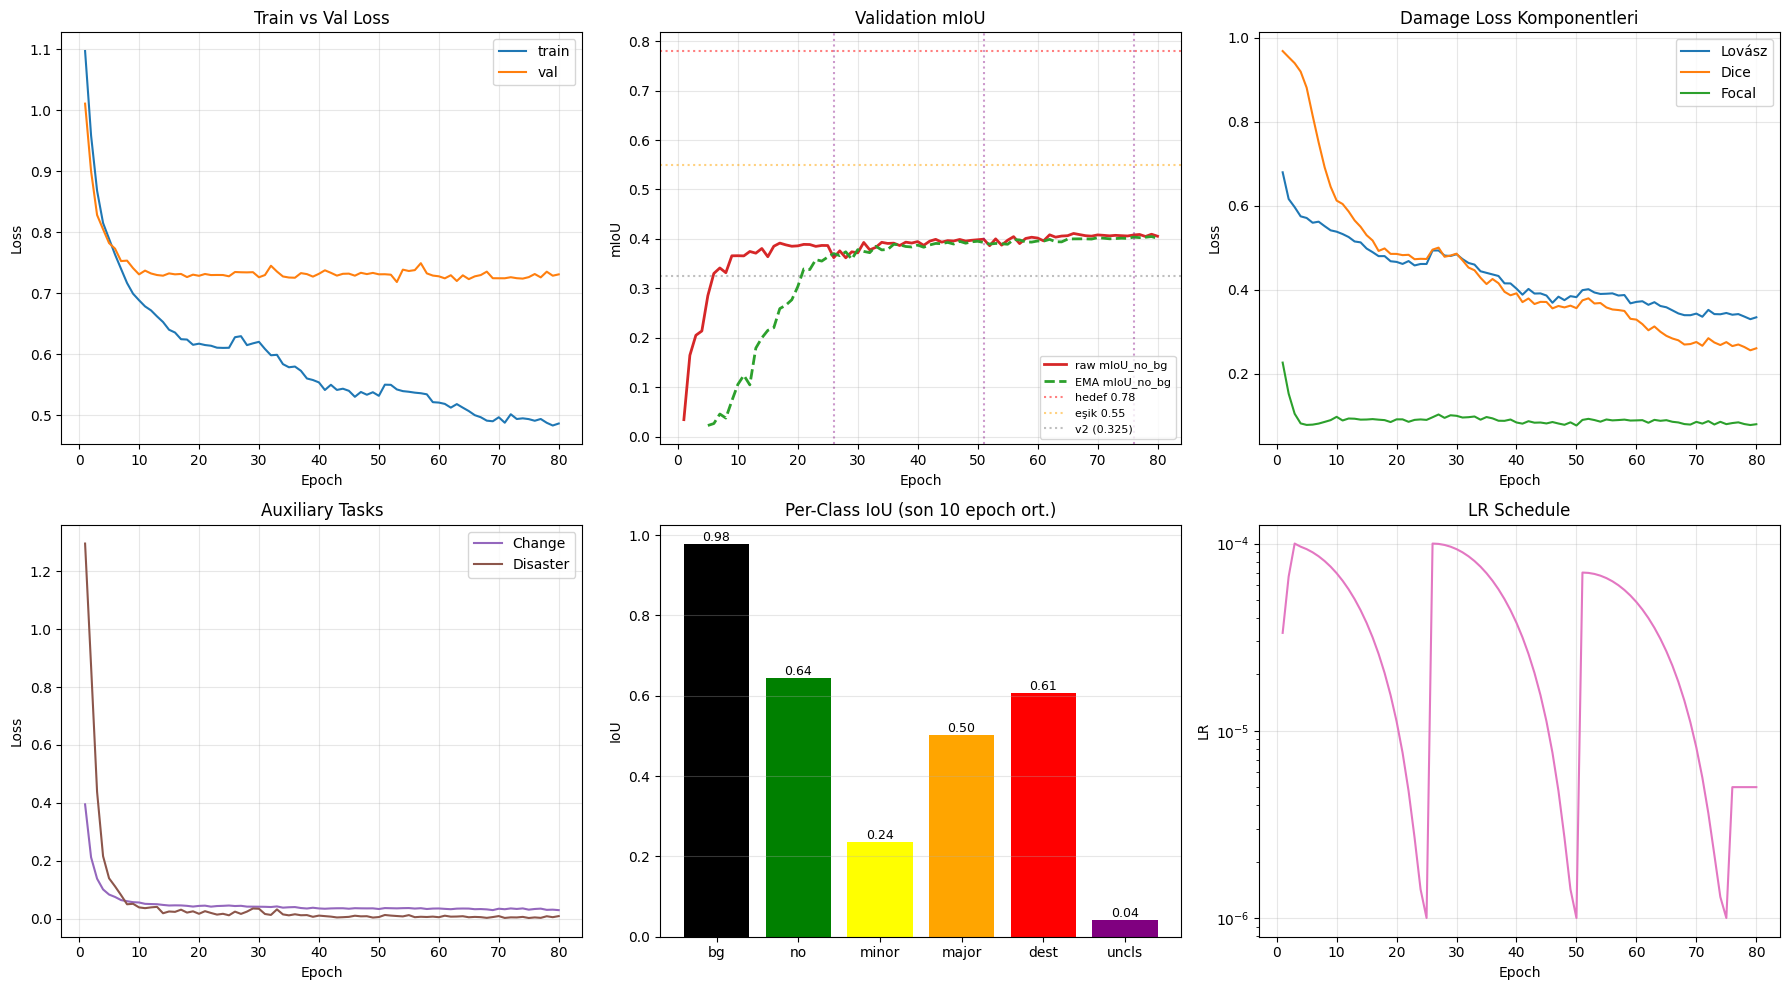


📊 Özet:
   Best raw mIoU_no_bg: 0.4110
   Best EMA mIoU_no_bg: 0.4048
   Toplam süre: 349.9 dk


In [ ]:
import matplotlib.pyplot as plt
import json
import numpy as np

with open(os.path.join(CKPT_TEACHER, "teacher_v3_history.json")) as f:
    history = json.load(f)

epochs = list(range(1, len(history["train_loss"]) + 1))

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Loss
ax = axes[0, 0]
ax.plot(epochs, history["train_loss"], label="train", color="C0")
ax.plot(epochs, history["val_loss"], label="val", color="C1")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Train vs Val Loss"); ax.legend(); ax.grid(alpha=0.3)

# mIoU (raw + EMA)
ax = axes[0, 1]
ax.plot(epochs, history["val_miou_no_bg"], label="raw mIoU_no_bg", color="C3", linewidth=2)
ema_vals = [v for v in history["val_miou_no_bg_ema"] if v is not None]
ema_epochs = [i + 1 for i, v in enumerate(history["val_miou_no_bg_ema"]) if v is not None]
if ema_vals:
    ax.plot(ema_epochs, ema_vals, label="EMA mIoU_no_bg", color="C2", linewidth=2, linestyle="--")
ax.axhline(y=0.78, color="red", linestyle=":", alpha=0.5, label="hedef 0.78")
ax.axhline(y=0.55, color="orange", linestyle=":", alpha=0.5, label="eşik 0.55")
ax.axhline(y=0.325, color="gray", linestyle=":", alpha=0.5, label="v2 (0.325)")
for r in [26, 51, 76]:
    if r <= len(epochs):
        ax.axvline(r, color="purple", linestyle=":", alpha=0.4)
ax.set_xlabel("Epoch"); ax.set_ylabel("mIoU")
ax.set_title("Validation mIoU"); ax.legend(loc="lower right", fontsize=8); ax.grid(alpha=0.3)

# Loss komponentleri
ax = axes[0, 2]
ax.plot(epochs, history["train_lovasz"], label="Lovász", color="C0")
ax.plot(epochs, history["train_dice"], label="Dice", color="C1")
ax.plot(epochs, history["train_focal"], label="Focal", color="C2")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Damage Loss Komponentleri"); ax.legend(); ax.grid(alpha=0.3)

# Aux task losses
ax = axes[1, 0]
ax.plot(epochs, history["train_change"], label="Change", color="C4")
ax.plot(epochs, history["train_disaster"], label="Disaster", color="C5")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Auxiliary Tasks"); ax.legend(); ax.grid(alpha=0.3)

# Per-class IoU
ax = axes[1, 1]
n_last = min(10, len(history["val_iou_per_class"]))
last_iou = [history["val_iou_per_class"][-(i+1)] for i in range(n_last)]
mean_iou = np.nanmean(last_iou, axis=0)
class_names_full = ["bg", "no", "minor", "major", "dest", "uncls"]
colors = ["black", "green", "yellow", "orange", "red", "purple"]
ax.bar(range(6), mean_iou, color=colors)
ax.set_xticks(range(6))
ax.set_xticklabels(class_names_full)
ax.set_ylabel("IoU")
ax.set_title(f"Per-Class IoU (son {n_last} epoch ort.)")
ax.grid(alpha=0.3, axis="y")
for i, v in enumerate(mean_iou):
    if not np.isnan(v):
        ax.text(i, v, f"{v:.2f}", ha="center", va="bottom", fontsize=9)

# LR
ax = axes[1, 2]
ax.plot(epochs, history["lr"], color="C6")
ax.set_xlabel("Epoch"); ax.set_ylabel("LR")
ax.set_title("LR Schedule"); ax.set_yscale("log"); ax.grid(alpha=0.3)

plt.tight_layout()
fig_path = os.path.join(OUTPUTS_VIZ, "teacher_v3_training_curves.png")
plt.savefig(fig_path, dpi=100, bbox_inches="tight")
print(f"✅ Kaydedildi: {fig_path}")
plt.show()

print(f"\n📊 Özet:")
print(f"   Best raw mIoU_no_bg: {max(history['val_miou_no_bg']):.4f}")
ema_clean = [v for v in history['val_miou_no_bg_ema'] if v is not None]
if ema_clean:
    print(f"   Best EMA mIoU_no_bg: {max(ema_clean):.4f}")
print(f"   Toplam süre: {sum(history['epoch_time']):.1f} dk")

## 8️⃣ Tahmin Görseli (EMA Model Tercihli)

In [ ]:
from matplotlib.colors import ListedColormap
import random

# EMA model varsa onu kullan
ema_path = os.path.join(CKPT_TEACHER, "teacher_v3_best_ema.pth")
raw_path = os.path.join(CKPT_TEACHER, "teacher_v3_best.pth")

if os.path.exists(ema_path):
    print("📂 EMA model yükleniyor (raw'dan daha iyi olabilir)...")
    ckpt = torch.load(ema_path, map_location=device, weights_only=False)
    print(f"   epoch={ckpt['epoch']}, mIoU_no_bg={ckpt['val_miou_no_bg']:.4f}")
else:
    print("📂 Raw model yükleniyor...")
    ckpt = torch.load(raw_path, map_location=device, weights_only=False)
    print(f"   epoch={ckpt['epoch']}, mIoU_no_bg={ckpt['val_miou_no_bg']:.4f}")

model.load_state_dict(ckpt["model_state_dict"])
model.eval()

CMAP_V2 = ListedColormap(np.array([
    [0, 0, 0], [0, 255, 0], [255, 255, 0],
    [255, 128, 0], [255, 0, 0], [200, 0, 200]
]) / 255.0)

random.seed(42)
sample_indices = random.sample(range(len(val_ds)), 4)

fig, axes = plt.subplots(4, 4, figsize=(20, 20))

for row, idx in enumerate(sample_indices):
    sample = val_ds[idx]
    img_batch = sample["image"].unsqueeze(0).to(device)

    with torch.no_grad():
        with torch.autocast(device_type="cuda", dtype=amp_dtype):
            out = model(img_batch)
        damage_out = out["damage_logits"]
        if isinstance(damage_out, list):
            main_logits = damage_out[0]
        else:
            main_logits = damage_out
        pred = main_logits.argmax(dim=1)[0].cpu()

    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    pre = ((sample["image"][:3] * std) + mean).permute(1, 2, 0).numpy().clip(0, 1)
    post = ((sample["image"][3:] * std) + mean).permute(1, 2, 0).numpy().clip(0, 1)

    axes[row, 0].imshow(pre)
    axes[row, 0].set_title("Pre" if row == 0 else "")
    axes[row, 0].axis("off")
    axes[row, 1].imshow(post)
    axes[row, 1].set_title("Post" if row == 0 else "")
    axes[row, 1].axis("off")
    axes[row, 2].imshow(sample["mask"].numpy(), cmap=CMAP_V2, vmin=0, vmax=5)
    axes[row, 2].set_title("GT" if row == 0 else "")
    axes[row, 2].axis("off")
    axes[row, 3].imshow(pred.numpy(), cmap=CMAP_V2, vmin=0, vmax=5)
    axes[row, 3].set_title("Prediction" if row == 0 else "")
    axes[row, 3].axis("off")

plt.suptitle(f"Teacher v3 — Phase 2 (mIoU_no_bg: {ckpt['val_miou_no_bg']:.4f})", fontsize=14, y=1.001)
plt.tight_layout()
pred_path = os.path.join(OUTPUTS_VIZ, "teacher_v3_predictions.png")
plt.savefig(pred_path, dpi=80, bbox_inches="tight")
print(f"✅ Kaydedildi: {pred_path}")
plt.show()

Output hidden; open in https://colab.research.google.com to view.

## 🎉 Phase 2 Tamamlandı!

### Drive'da

```
checkpoints/teacher/
├── teacher_best.pth         (v1: 0.298)
├── teacher_v2_best.pth      (v2: 0.325)
├── teacher_v3_best.pth      (v3 raw)         ← YENİ
├── teacher_v3_best_ema.pth  (v3 EMA - genelde daha iyi) ← YENİ
├── localizer_best.pth       (Phase 1)
└── teacher_v3_history.json
```

### Bana Ne Göndereceksin

1. **Son 10 epoch console log** — özellikle EMA satırları
2. **`teacher_v3_training_curves.png`**
3. **`teacher_v3_predictions.png`**

### Sonraki Adım

Sonuca göre:
- **mIoU_no_bg ≥ 0.55** → Notebook 3 (öğrenci + KD) hazır
- **0.45-0.55** → Bir kaç epoch ek fine-tune deneyebiliriz
- **< 0.45** → Daha derin debug

---

**Calamitas AI · Teknofest 2025 · Phase 2/2** 🚀